# **1. 문제 정의 및 데이터 이해**

**목표 설정**

- 비즈니스 문제: 통신사 고객 이탈을 예측하여 선제적 유지 전략 수립
- 분석 목표: 이탈에 영향을 미치는 주요 요인 파악 및 이탈 예측 모델 구축
- 성공 지표: 모델 정확도, Precision/Recall, F1-score, 비즈니스 액션 가능성 등

**데이터셋 구조 파악**

- churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
- 데이터 크기, 변수 개수, 데이터 타입 확인
- 각 변수의 의미와 비즈니스 맥락 이해

## 데이터셋 구조 파악

In [5]:

import pandas as pd

#churn-80.csv (훈련/검증용), churn-20.csv (최종 테스트용) 파일 로드
df = pd.read_csv('churn-bigml-80.csv')
df1 = pd.read_csv('churn-bigml-20.csv')

#데이터 크기, 변수 개수, 데이터 타입 확인
df.head(20)
df.shape
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

#각 변수의 의미와 비즈니스 맥락 이해

| 컬럼명                        | 의미                        | 
| -------------------------- | ------------------------- | 
| **State**                  | 고객이 거주하는 주(State)         |
| **Account length**         | 고객 계정 유지 기간(일)            | 
| **Area code**              | 지역 전화 코드                  | 
| **International plan**     | 국제전화 요금제 사용 여부 (Yes/No)   | 
| **Voice mail plan**        | 음성 사서함 요금제 사용 여부 (Yes/No) | 
| **Number vmail messages**  | 음성 사서함 메시지 수              | 
| **Total day minutes**      | 주간 통화 총 시간(분)             | 
| **Total day calls**        | 주간 통화 횟수                  | 
| **Total day charge**       | 주간 통화 요금                  | 
| **Total eve minutes**      | 저녁 통화 총 시간(분)             | 
| **Total eve calls**        | 저녁 통화 횟수                  | 
| **Total eve charge**       | 저녁 통화 요금                  | 
| **Total night minutes**    | 야간 통화 총 시간(분)             | 
| **Total night calls**      | 야간 통화 횟수                  | 
| **Total night charge**     | 야간 통화 요금                  | 
| **Total intl minutes**     | 국제 통화 총 시간(분)             | 
| **Total intl calls**       | 국제 통화 횟수                  | 
| **Total intl charge**      | 국제 통화 요금                  |
| **Customer service calls** | 고객센터 문의 횟수                | 
| **Churn**                  | 고객 이탈 여부 (True/False)     | 


# **2. 데이터 전처리**

**결측치 처리**

- 결측치 존재 여부 확인
- 결측치 처리 전략 수립: 삭제, 평균/중앙값 대체, 또는 별도 카테고리 생성
- 처리 방법에 대한 근거 수립

**이상치 탐지 및 처리**

- 이상치가 실제 오류인지 극단값인지 판단
- 비즈니스 맥락을 고려한 처리 방법 결정 (유지/제거/변환 등)

**데이터 타입 변환**

- 범주형 변수(State, International plan, Voice mail plan) 식별
- 수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
- 필요시 변수 타입 변환 및 인코딩
    - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등

## 결측치 처리

In [6]:
#결측치 존재 여부 확인
df.isnull().sum()

#결측치 없음
df.isnull().any()

State                     False
Account length            False
Area code                 False
International plan        False
Voice mail plan           False
Number vmail messages     False
Total day minutes         False
Total day calls           False
Total day charge          False
Total eve minutes         False
Total eve calls           False
Total eve charge          False
Total night minutes       False
Total night calls         False
Total night charge        False
Total intl minutes        False
Total intl calls          False
Total intl charge         False
Customer service calls    False
Churn                     False
dtype: bool

## 이상치 탐지 및 처리

In [7]:
#이상치가 실제 오류인지 극단값인지 판단
#이상치는 수치형 변수에서만 확인할 수 있으므로 수치형 변수 선택
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

#IQR을 사용하여 이상치가 있는 컬럼들 확인
def find_outlier_columns_iqr(df, num_cols):
    outlier_cols = []

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if ((df[col] < lower) | (df[col] > upper)).any():
            outlier_cols.append(col)

    return outlier_cols


#이상치가 있는 컬럼 총 15개
outlier_columns = find_outlier_columns_iqr(df, num_cols)
outlier_columns



['Account length',
 'Number vmail messages',
 'Total day minutes',
 'Total day calls',
 'Total day charge',
 'Total eve minutes',
 'Total eve calls',
 'Total eve charge',
 'Total night minutes',
 'Total night calls',
 'Total night charge',
 'Total intl minutes',
 'Total intl calls',
 'Total intl charge',
 'Customer service calls']

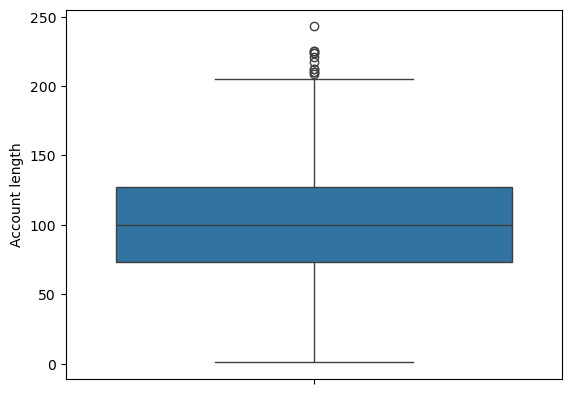

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.boxplot(df['Account length'])
plt.show()

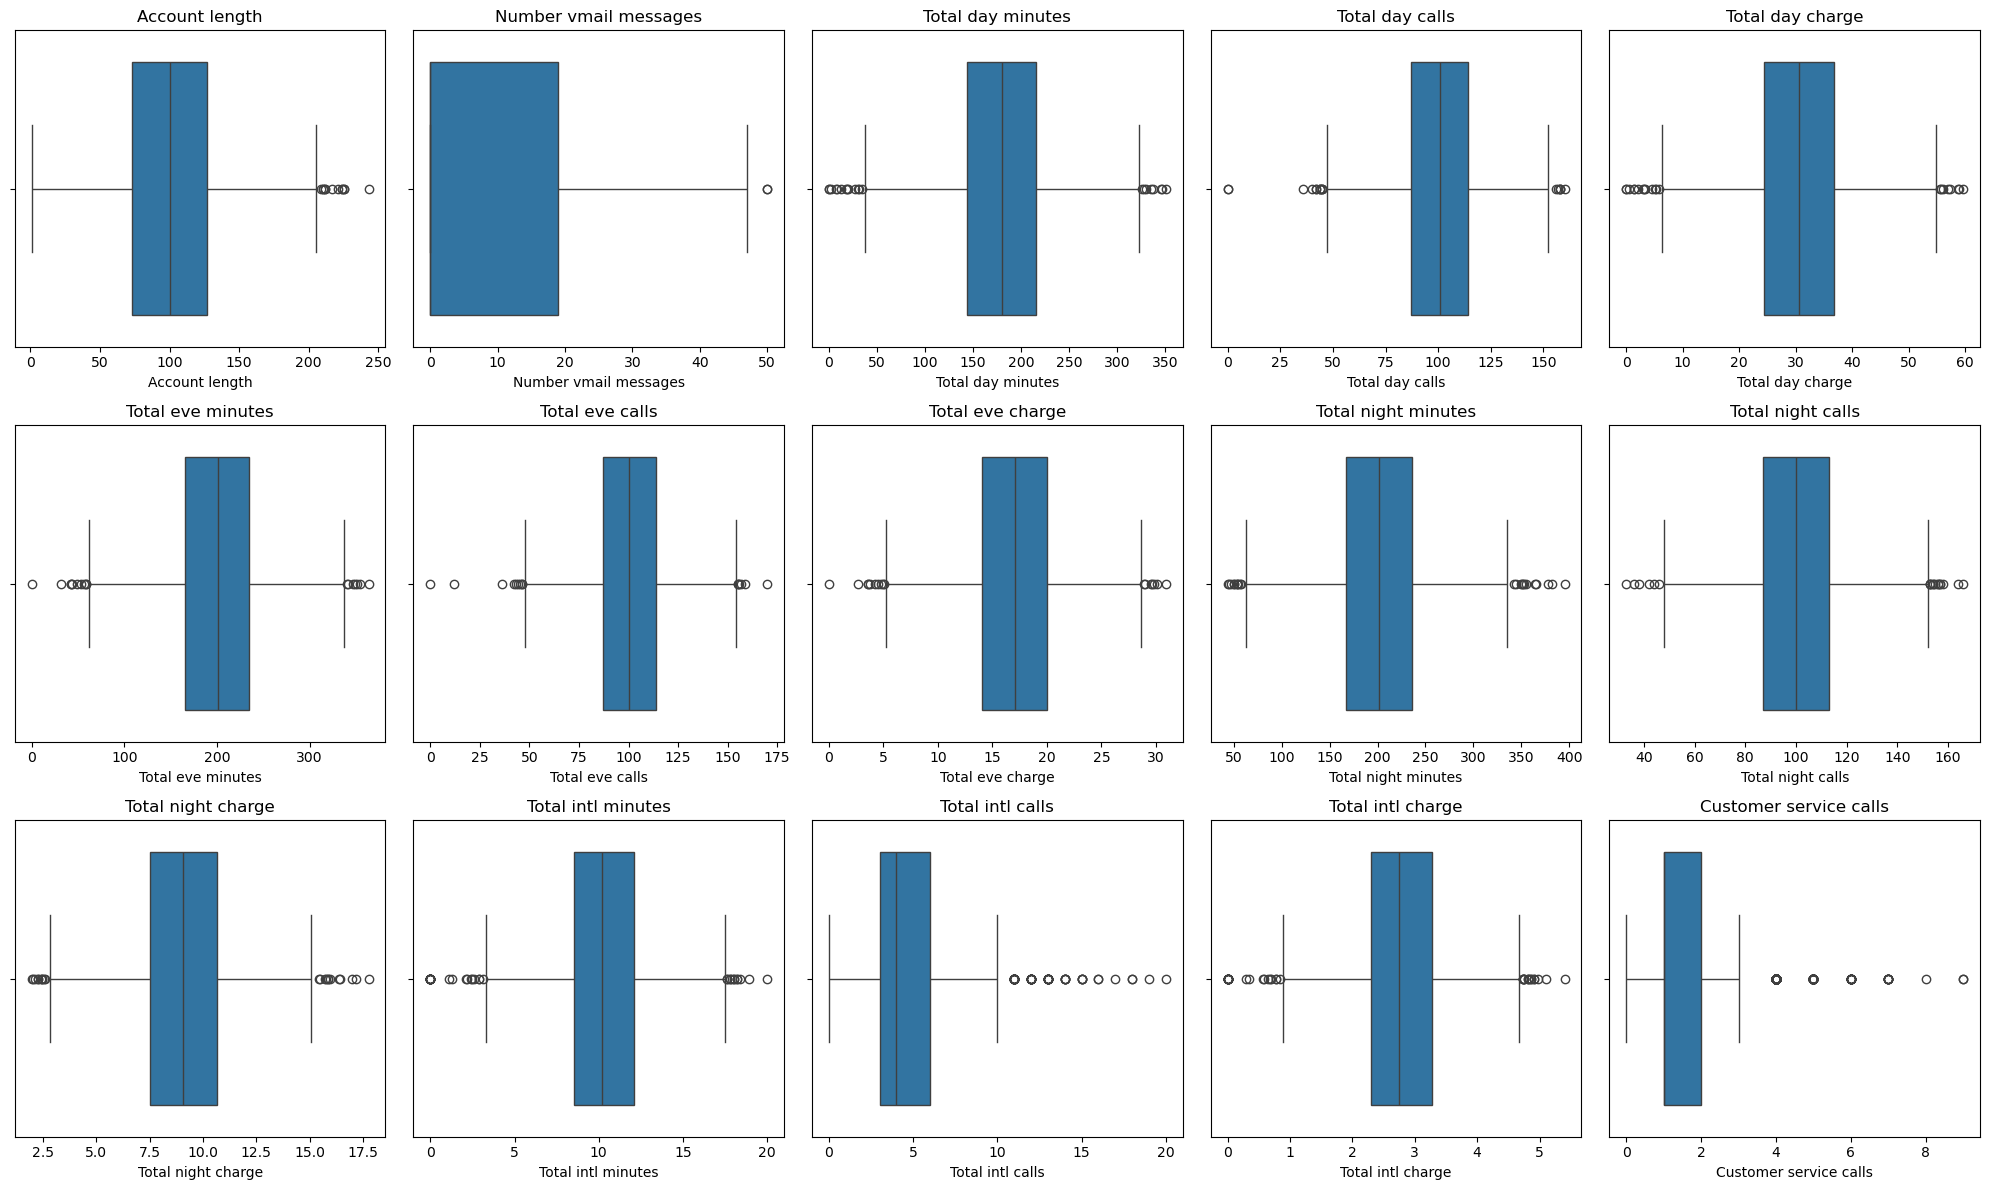

In [9]:

#이상치가 있는 컬럼들에 대해 박스플롯 그림
outlier_cols = outlier_columns


fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### 비즈니스 맥락을 고려한 처리 방법 결정 (유지/제거/변환 등)

각각 컬럼의 이상치를 확인해보았을 때 특별히 오류값이라고 판단되거나 의미없는 값이라고 생각되는 컬럼이 없어서
우선 컬럼들은 다 유지하기로 결정함


## 데이터 타입 변환
- 범주형 변수(State, International plan, Voice mail plan) 식별
- 수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
- 필요시 변수 타입 변환 및 인코딩
    - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등

In [10]:
#수치형 변수 식별
num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

#범주형 변수 식별
df.dtypes
notnum_cols = df.select_dtypes(exclude=['int64','float64']).columns
print(notnum_cols)

#수치형 변수 스케일 확인 (통화 시간, 요금, 횟수 등)
df.describe()


Index(['Account length', 'Area code', 'Number vmail messages',
       'Total day minutes', 'Total day calls', 'Total day charge',
       'Total eve minutes', 'Total eve calls', 'Total eve charge',
       'Total night minutes', 'Total night calls', 'Total night charge',
       'Total intl minutes', 'Total intl calls', 'Total intl charge',
       'Customer service calls'],
      dtype='object')
Index(['State', 'International plan', 'Voice mail plan', 'Churn'], dtype='object')


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

#필요시 변수 타입 변환 및 인코딩  - ex) yes→1, no→0 / 라벨 인코딩 / 원핫 인코딩 등
df.dtypes
notnum_cols = df.select_dtypes(exclude=['int64','float64']).columns
print(notnum_cols)

#'State', 'International plan', 'Voice mail plan', 'Churn'
for col in notnum_cols:
    print(f"범주형 변수 값 종류 : {df[col].unique()}")
    print(f"범주형 변수 값 분포 : {df[col].value_counts()}")




Index(['State', 'International plan', 'Voice mail plan', 'Churn'], dtype='object')
범주형 변수 값 종류 : ['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'WV' 'RI' 'IA' 'MT' 'ID' 'VT' 'VA'
 'TX' 'FL' 'CO' 'AZ' 'NE' 'WY' 'IL' 'NH' 'LA' 'GA' 'AK' 'MD' 'AR' 'WI'
 'OR' 'DE' 'IN' 'UT' 'CA' 'SD' 'NC' 'WA' 'MN' 'NM' 'NV' 'DC' 'NY' 'KY'
 'ME' 'MS' 'MI' 'SC' 'TN' 'PA' 'HI' 'ND' 'CT']
범주형 변수 값 분포 : State
WV    88
MN    70
NY    68
VA    67
AL    66
OH    66
WY    66
OR    62
NV    61
WI    61
MD    60
UT    60
CO    59
CT    59
MI    58
VT    57
ID    56
NC    56
TX    55
FL    54
IN    54
MT    53
OK    52
MA    52
KS    52
MO    51
DE    51
NJ    50
SC    49
SD    49
ME    49
GA    49
RI    48
MS    48
WA    48
AR    47
IL    45
DC    45
AZ    45
NE    45
HI    44
NM    44
ND    44
AK    43
KY    43
NH    43
TN    41
IA    38
PA    36
LA    35
CA    24
Name: count, dtype: int64
범주형 변수 값 종류 : ['No' 'Yes']
범주형 변수 값 분포 : International plan
No     2396
Yes     270
Name: count, dtype: int64
범주형 변수 값 종류 : ['Yes' 'No']
범

In [12]:
#원본값을 그대로 두고, bin 값으로 컬럼 생성하여 변경
df['International_plan_bin'] = df['International plan'].map({'No': 0, 'Yes': 1})
df['Voice_mail_plan_bin'] = df['Voice mail plan'].map({'No': 0, 'Yes': 1})

In [13]:
#데이터 확인
df.head(10)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,International_plan_bin,Voice_mail_plan_bin
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,0,1
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,0,1
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,1,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1,0
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False,1,0
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False,0,1
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False,1,0
8,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False,1,1
9,RI,74,415,No,No,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,False,0,0


## **3. EDA**

**단변량 분석 (Univariate Analysis)**

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

**이변량 분석 (Bivariate Analysis)**

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등

**다변량 분석 (Multivariate Analysis)**

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)

**비즈니스 인사이트 도출**

- 이탈 고객의 주요 특징 3-5가지 정리
- 지역별/요금제별 이탈률 차이 분석
- 고위험 고객 프로필 정의
- EDA 결과를 바탕으로 가설 수립

### 단변량 분석 (Univariate Analysis)

- 수치형 변수: 히스토그램, 박스플롯으로 분포 확인
- 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
- 범주형 변수: 빈도표, 막대그래프로 분포 확인
- 타겟 변수(Churn) 불균형 비율 계산

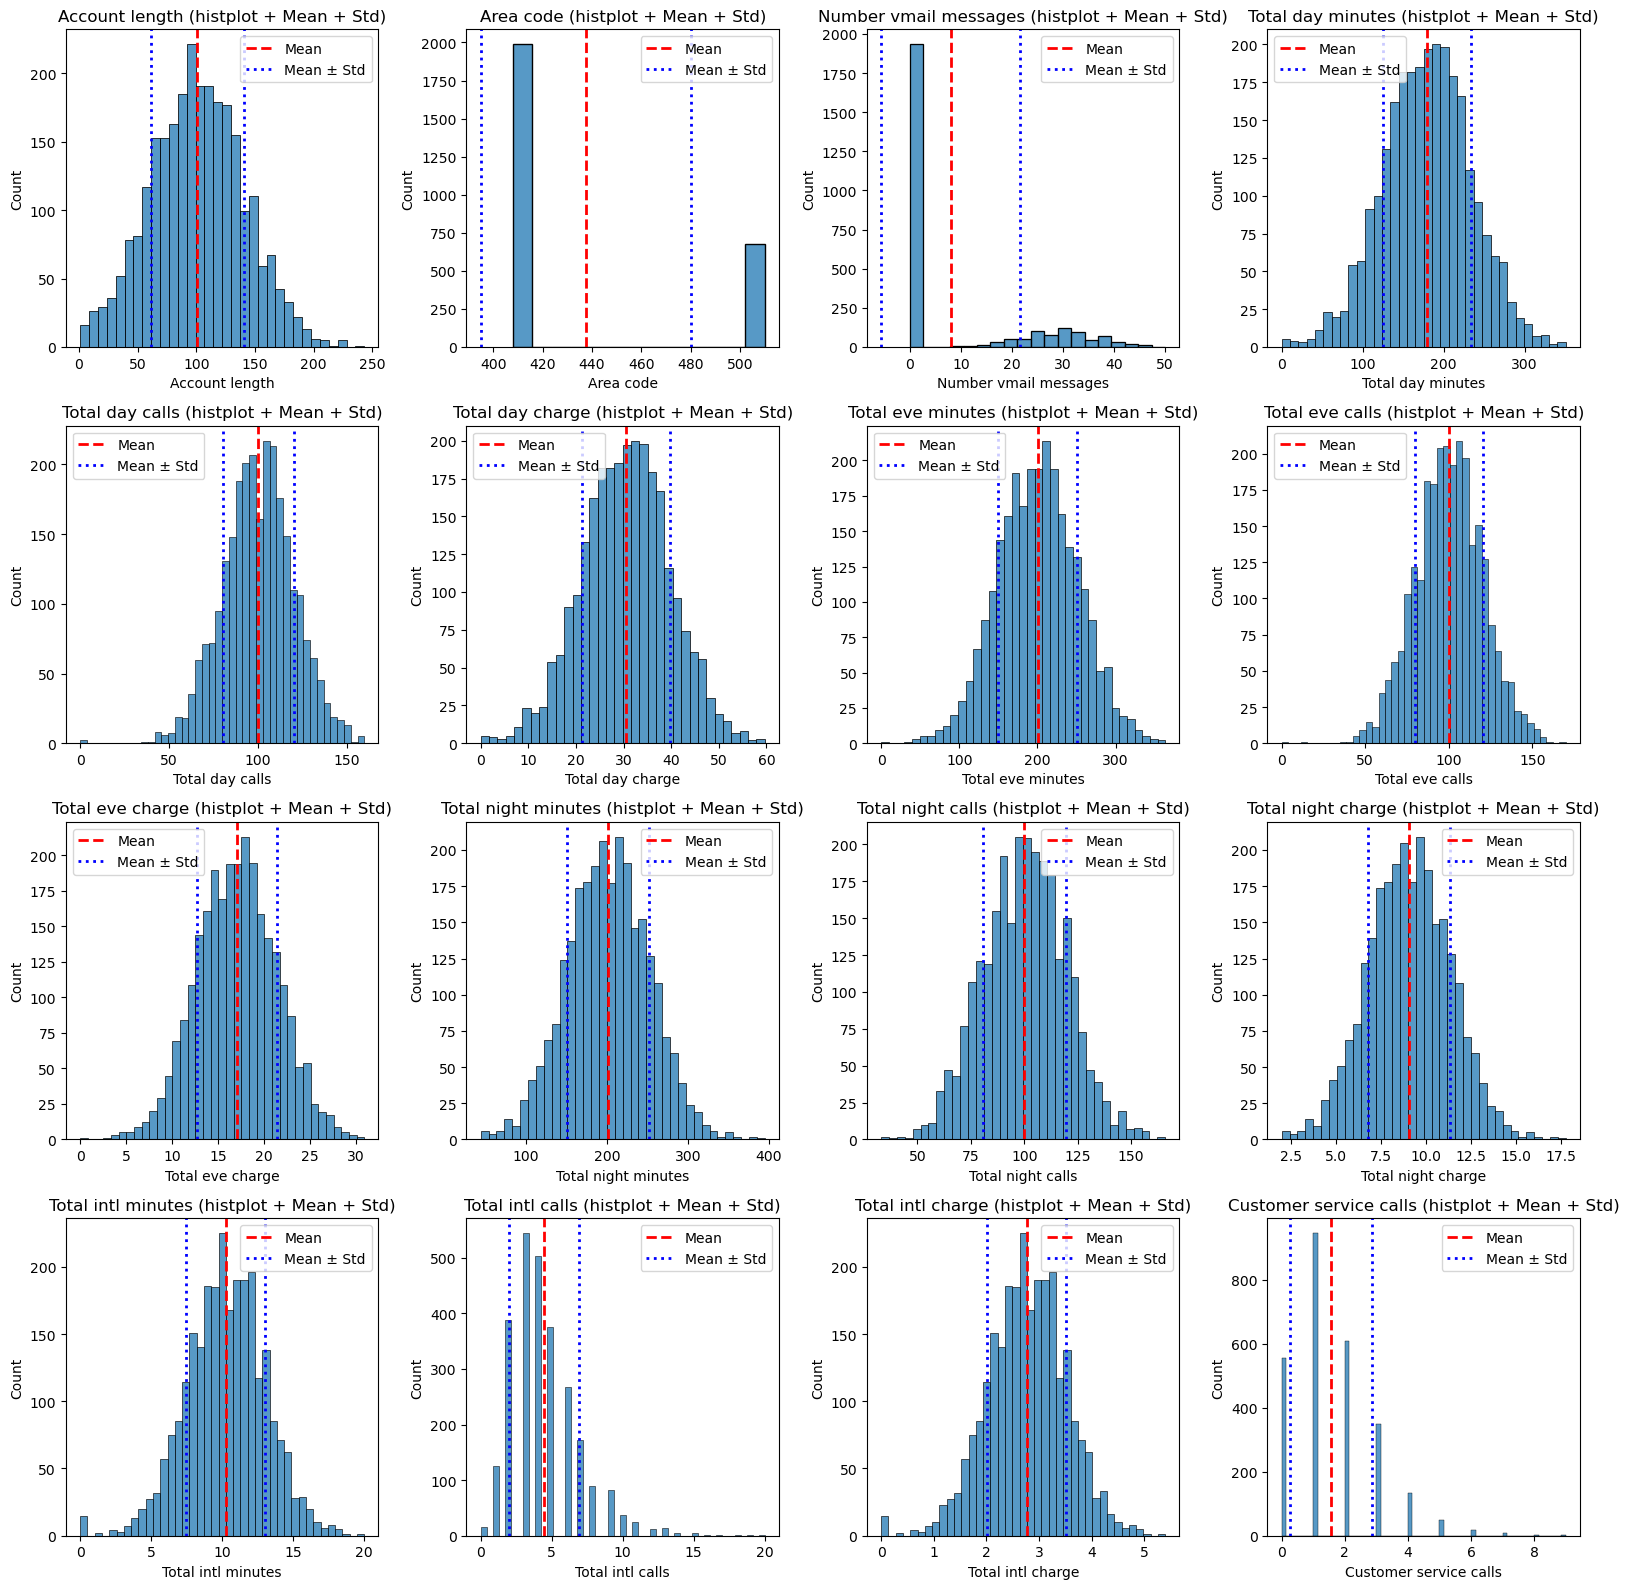

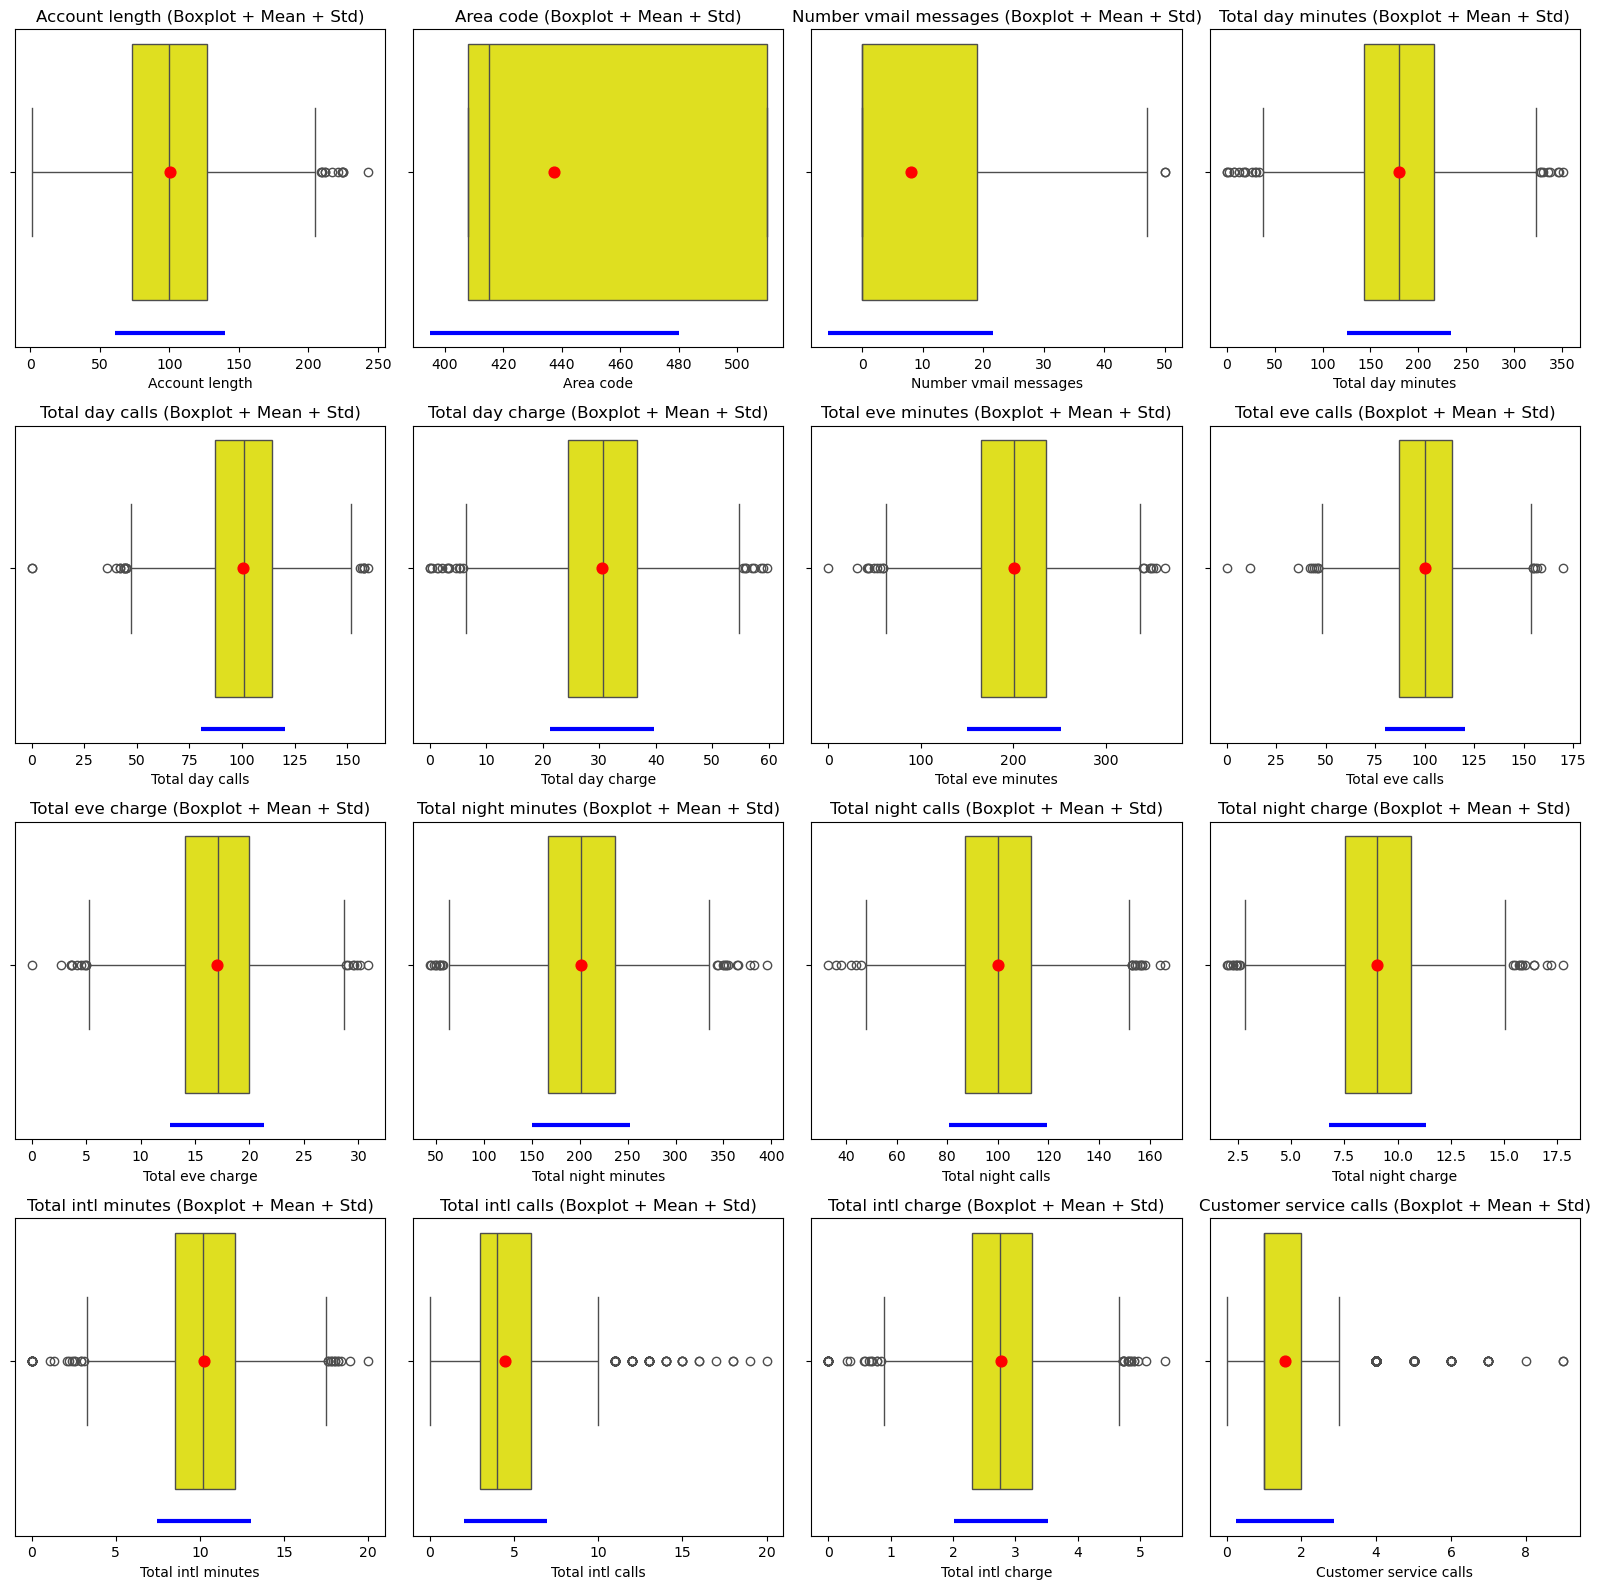

In [14]:

#수치형 변수: 히스토그램 분포 확인

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    mean_val = df[col].mean()
    std_val = df[col].std()
    sns.histplot(df[col], ax=axes[i])

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')
    
    axes[i].axvline(mean_val - std_val, color='blue', linestyle=':', linewidth=2, label='Mean ± Std')
    axes[i].axvline(mean_val + std_val, color='blue', linestyle=':', linewidth=2)
    axes[i].set_title(col)

    axes[i].legend()
    axes[i].set_title(f'{col} (histplot + Mean + Std)')

plt.tight_layout()
plt.show()

#수치형 변수 : 기술통계량 산출 (평균, 중앙값, 표준편차, 사분위수)
fig, axes = plt.subplots(4, 4, figsize=(16,16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='yellow')
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    axes[i].scatter(mean_val, 0, color='red', s=60, zorder=3)
    axes[i].hlines(
    y=0.5,
    xmin=mean_val - std_val,
    xmax=mean_val + std_val,
    color='blue',
    linewidth=3,
    zorder=2
)
    
    axes[i].set_title(f'{col} (Boxplot + Mean + Std)')

plt.tight_layout()
plt.show()

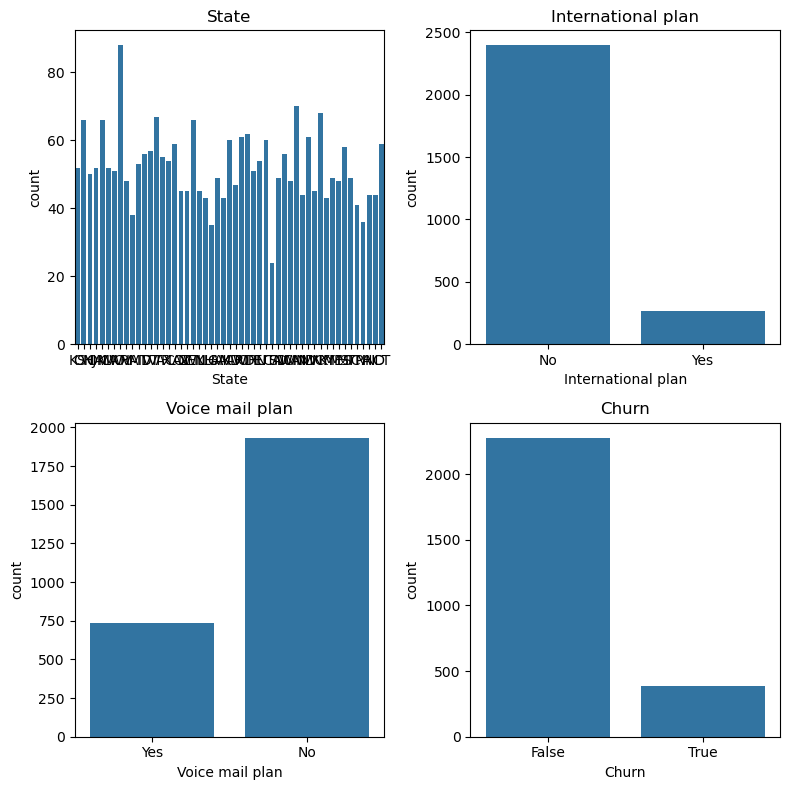

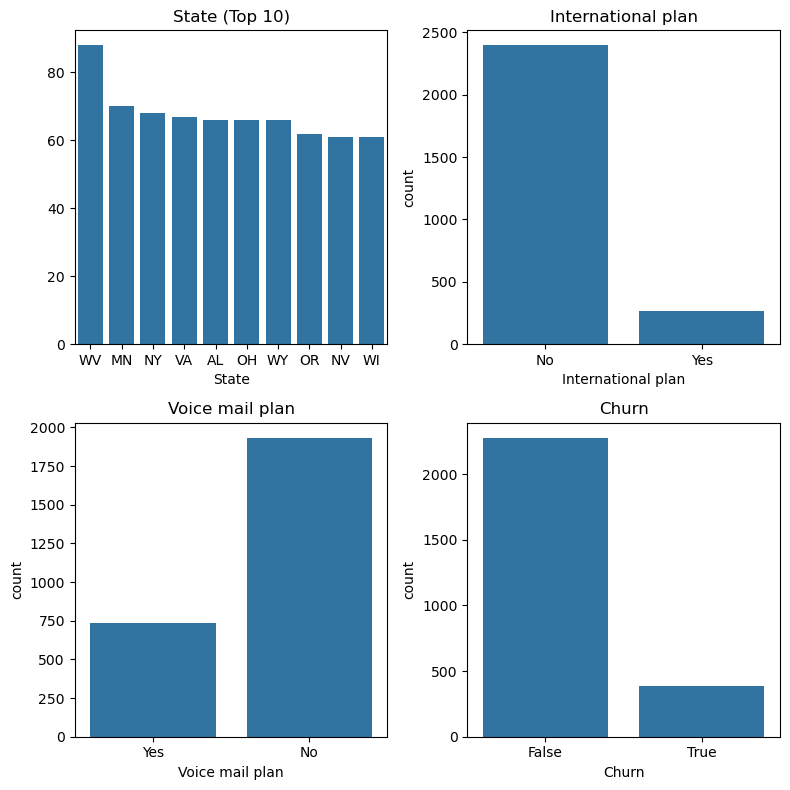

In [15]:
#범주형 변수 막대그래프 확인

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(notnum_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()


#state 컬럼값이 너무 많아서 상위20개만 확인
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i, col in enumerate(notnum_cols):
    if col == 'State':
        counts = df[col].value_counts().head(10)
        sns.barplot(
            x=counts.index,
            y=counts.values,
            ax=axes[i]
        )
        axes[i].set_title(f'{col} (Top 10)')
    else:
        sns.countplot(x=col, data=df, ax=axes[i])
        axes[i].set_title(col)
        

plt.tight_layout()
plt.show()


범주형 변수 중에서
state는 값이 다양하고 분포도 크게 차이가 나지 않아서 의미가 없어보이지만,

단일값으로만 확정할 수는 없기에 이변량 또는 다변량에서 한번 더 확인을 해보고 분석에서 제외해도 될지를 선택해도 좋을 것 같습니다.

<function matplotlib.pyplot.show(close=None, block=None)>

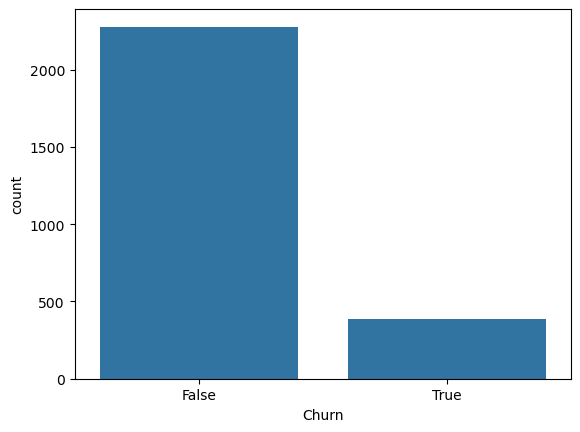

In [16]:
#타겟 변수(Churn) 불균형 비율 계산

df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)*100

sns.countplot(x='Churn', data=df)
plt.show

### 이변량 분석 (Bivariate Analysis)

- 수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
- 범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교
- 통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인
- 핵심 인사이트 도출: "고객 서비스 호출이 4회 이상인 고객의 이탈률이 50% 이상" 등

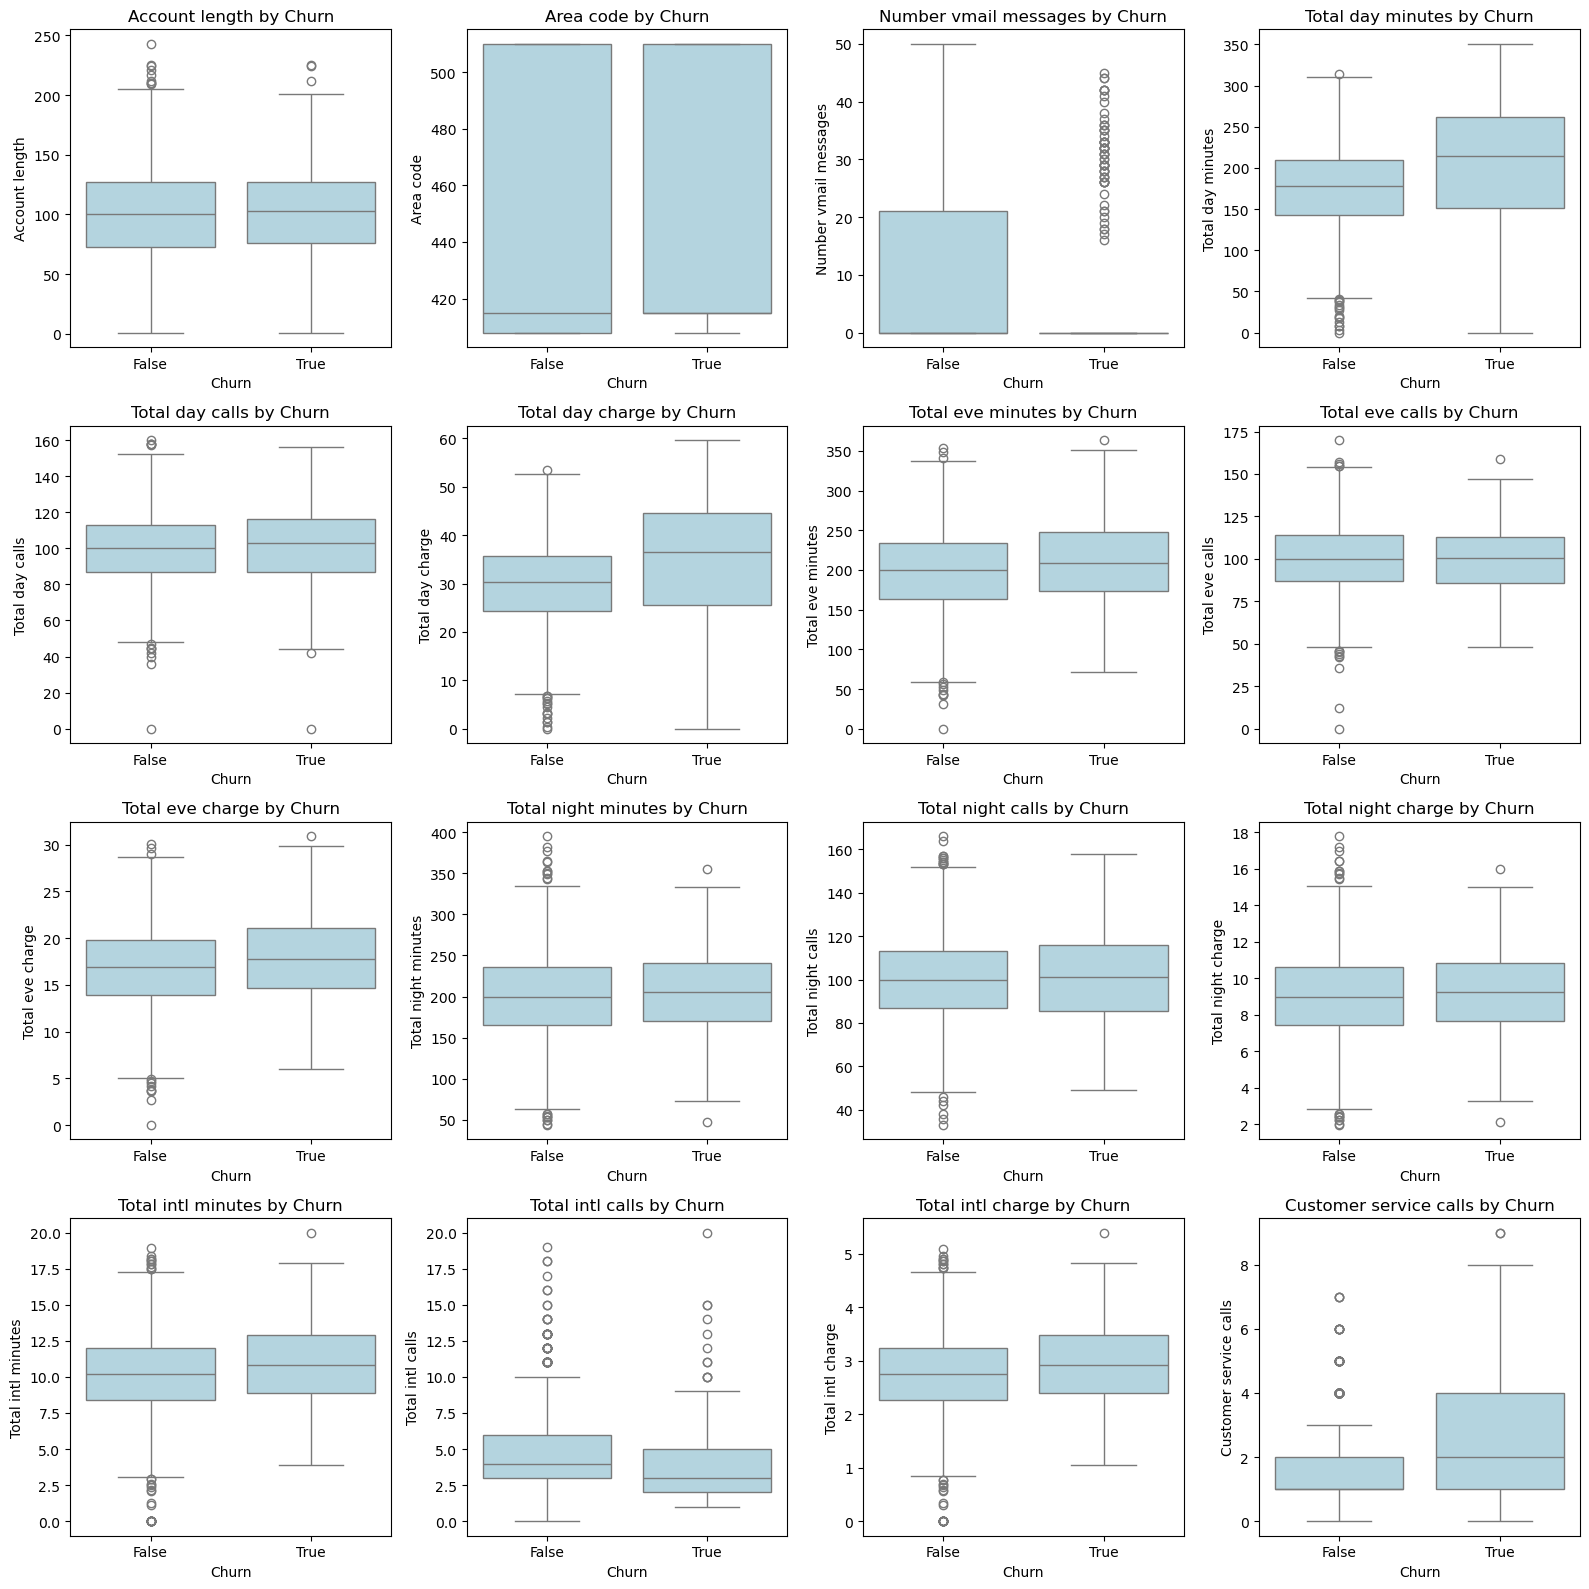

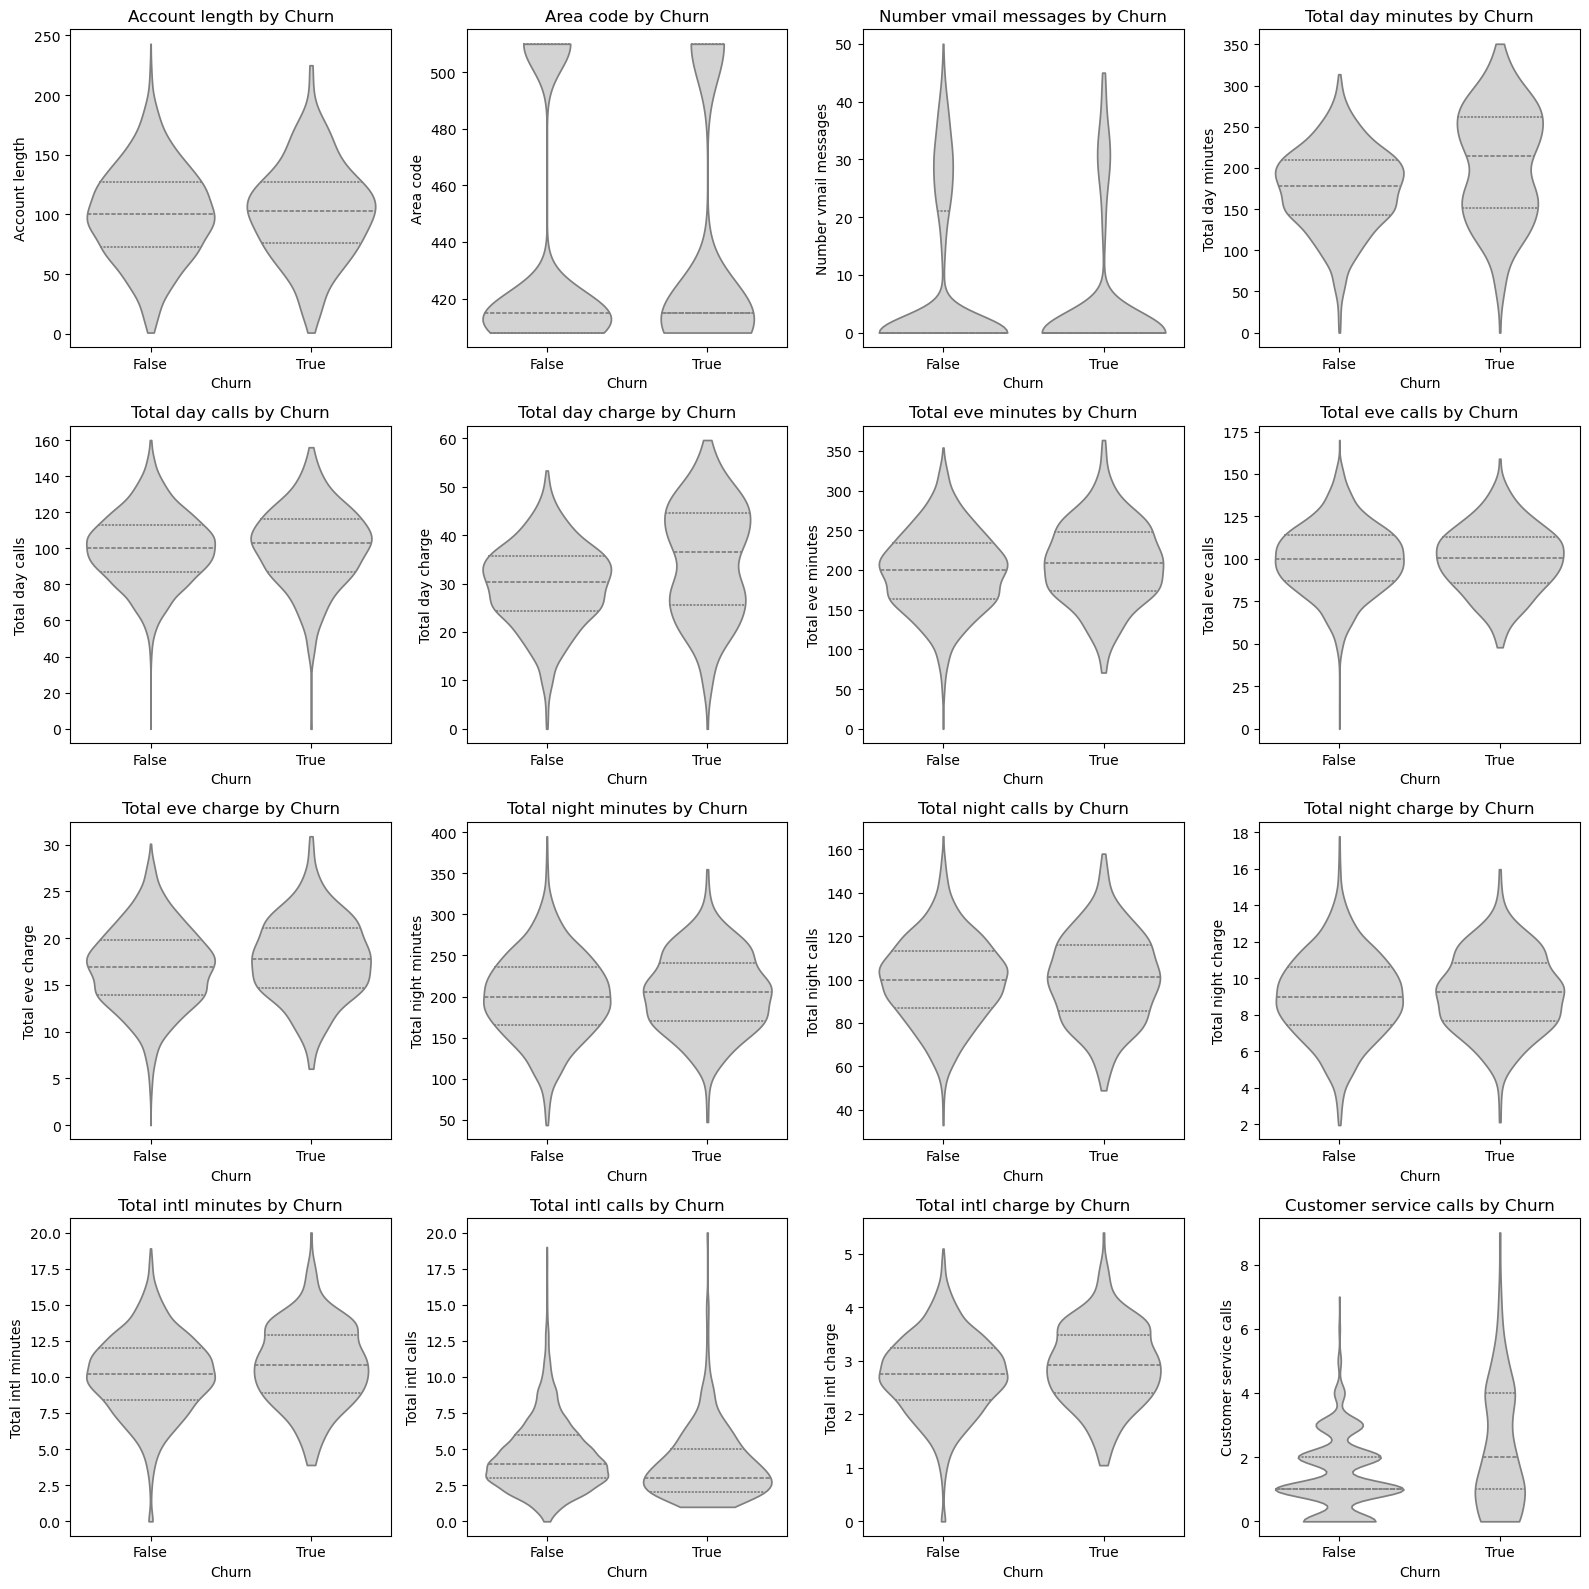

In [17]:
#수치형 변수 vs Churn: 박스플롯, 바이올린 플롯으로 그룹 간 차이 확인
#박스플롯
fig, axes = plt.subplots(4,4, figsize=(16,16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x='Churn',
        y=col,
        data=df,
        ax=axes[i],
        color = 'lightblue'

    )
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')

plt.tight_layout()
plt.show()


#바이올린 플롯
fig, axes = plt.subplots(4,4, figsize=(16,16))
axes = axes.flatten()


for i, col in enumerate(num_cols):
    sns.violinplot(
        x='Churn',
        y=col,
        data=df,
        ax=axes[i],
        inner='quartile',   # 사분위수 표시
        cut=0,               # 범위 밖 꼬리 제거
        color='lightgrey'
    )
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn')


plt.tight_layout()
plt.show()


이변량 변수 분석을 진행해본 결과 가장 눈에 띄는 것은

1) 고객 서비스 통화량(Customer service calls)
박스플롯에서
고객이 이탈한 경우(churn=true) 일때, 중앙값 범위가 눈에 띄게 넓고 false일때보다 더 위쪽에 위치해있습니다. 가장 큰 이상치도 true에 위치해 있습니다.

2) 주간 통화시간(Total day minutes) / 주간 통화 요금(Total day charge) (2개의 변수에 대해 박스플롯, 바이올린플롯 모두 비슷함)
박스플롯에서
고객이 이탈한 경우(churn=true) 일때, 동일하게 중앙값이 false일 때보다 크고 위에 위치해있음

3) 음성사서함 메세지 수(number vmail messages)
박스플롯에서 고객이 이탈한 경우 메세지 수가 거의 0. 고객이 이탈하지 않은 경우 메세지가 있는 경우가 많음

4) 국제전화 통화 횟수 (Total intl calls)
박스플롯에서
고객이 이탈한 경우 일대, 중앙값이 더 아래쪽에 위치해있음. day/eve/night의 경우 calls는 중앙값이 비슷했는데
국제전화에서는 다른 경향을 보임


-> 이를 통해 이와 관련된 변수들이 유의미하다고 판단함
number vmail messages
total day minutes
tdtal day calls
total day charge
total intl minutes 
total intl charge
total intl calls
customer serivce calls


반대로
저녁 (Total eve minutes)/calls/charge
야간 (Total night minutes)/calls/charge
관련 변수들은 크게 의미가 없다고 생각되어서 제외해도 될 것이라 생각함.
다만, 다변량 분석까지 다하고 최종 결정하기로 팀원들과 이야기함




State 교차표(Crosstab)

[Crosstab]
Churn  False  True 
State              
AK        40      3
AL        59      7
AR        36     11
AZ        42      3
CA        19      5
CO        52      7
CT        48     11
DC        40      5
DE        43      8
FL        47      7
GA        41      8
HI        42      2
IA        35      3
ID        51      5
IL        41      4
IN        48      6
KS        42     10
KY        37      6
LA        32      3
MA        44      8
MD        46     14
ME        38     11
MI        45     13
MN        57     13
MO        46      5
MS        37     11
MT        43     10
NC        47      9
ND        40      4
NE        41      4
NH        34      9
NJ        36     14
NM        40      4
NV        48     13
NY        56     12
OH        56     10
OK        45      7
OR        55      7
PA        28      8
RI        45      3
SC        38     11
SD        43      6
TN        36      5
TX        39     16
UT        52      8
VA        63      4
VT      

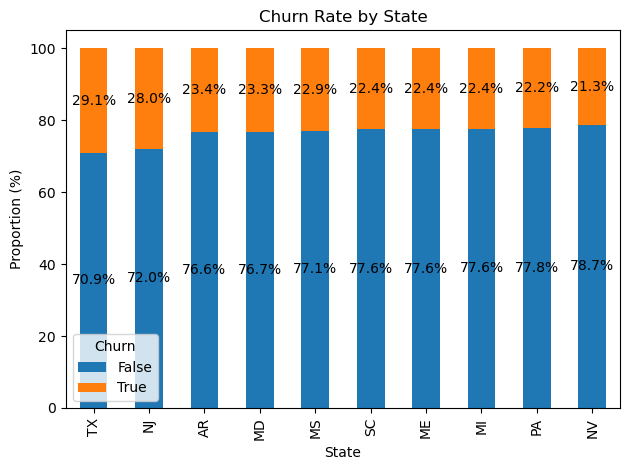

International plan 교차표(Crosstab)

[Crosstab]
Churn               False  True 
International plan              
No                   2126    270
Yes                   152    118
이탈률 : Churn                   False      True 
International plan                      
No                  88.731219  11.268781
Yes                 56.296296  43.703704


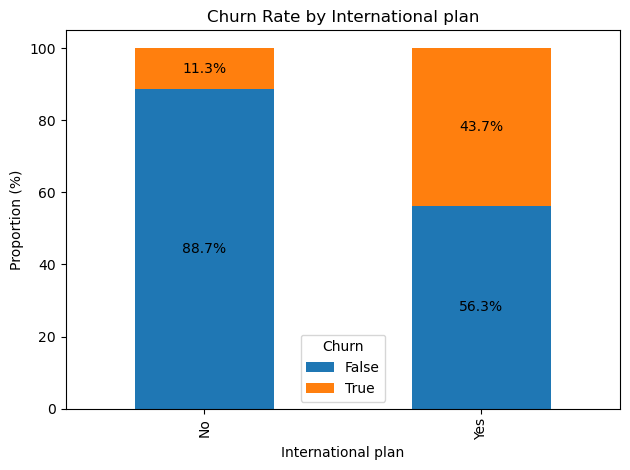

Voice mail plan 교차표(Crosstab)

[Crosstab]
Churn            False  True 
Voice mail plan              
No                1610    323
Yes                668     65
이탈률 : Churn                False      True 
Voice mail plan                      
No               83.290222  16.709778
Yes              91.132333   8.867667


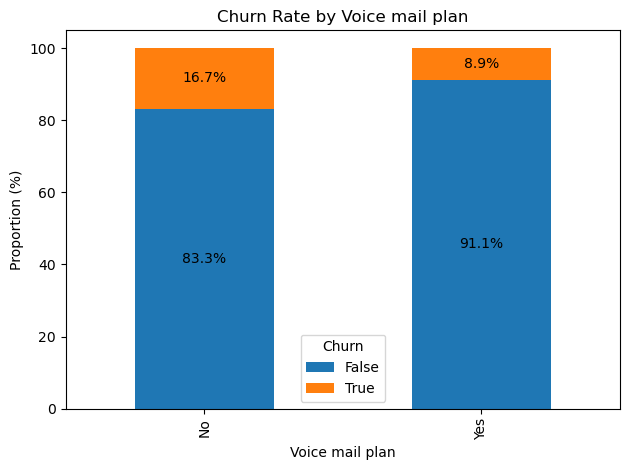

In [18]:

#범주형 변수 vs Churn: 교차표(Crosstab), 스택 바 차트로 이탈률 비교

for col in notnum_cols:
    

    #위에서 만든 notnum_cols에 churn가 포함되어있어서 churn은 넘어가도록
    if col == 'Churn':
        continue
    #교차표(Crosstab)
    print(f"{col} 교차표(Crosstab)")
    crosstab_count = pd.crosstab(df[col], df['Churn'])
    print('\n[Crosstab]')
    print(crosstab_count)

    #이탈률
    crosstab_rate = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100

    print(f"이탈률 : {crosstab_rate}")

    plot_data = crosstab_rate.copy()

    #State는 값이 너무 다양해서 상위 10개만 
    if col == 'State':    
        plot_data = plot_data.sort_values(by=True, ascending=False).head(10)

    #스택 바 차트
    ax = plot_data.plot(
        kind='bar',
        stacked=True
    )

    #막대 안에 % 나오도록 표시
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',     
            label_type='center'
    )

    plt.title(f'Churn Rate by {col}')
    plt.ylabel('Proportion (%)')
    plt.xlabel(col)
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()

1) International plan
국제전화 요금제 가입 여부에서 가장 큰 차이가 보임
국제전화 요금제를 가입한 사람들의 고객 이탈률이 43.7% 
가입하지 않은 사람들은 11.3%

국제전화 요금제를 가입한 사람들이 이탈하는 경향이 크게 보임

2) Voice mail plan
음성사서함 요금제 가입 여부에서 차이가 보임
음성사서함 요금제 가입을 안한 사람들의 고객 이탈률이 그렇지 않은 사람들의 약 2배

음성사서함 요금제 가입을 한 사람들이 이탈하지 않는 경향이 보임

3) State
주 (지역)에 따른 이탈률은 큰 차이가 없어보임
데이터 범주가 넓어서 상위 10개만 했는데, 상위 5개 & 하위 5개로 해보면 다를 수 도 있겠다는 생각이 듦



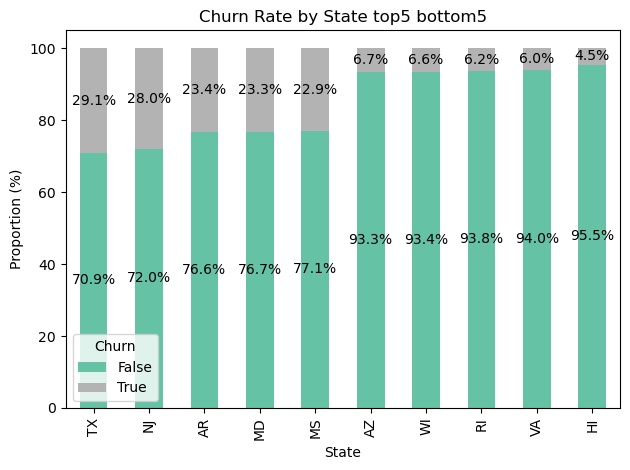

In [19]:
#이탈률
crosstab_rate = pd.crosstab(
                        df['State'],
                        df['Churn'],
                        normalize='index'
                    ) * 100

plot_data = crosstab_rate.copy()

#State는 값 상위 5개, 하위 5개
top5 = plot_data.sort_values(by=True, ascending=False).head(5)
bottom5 = plot_data.sort_values(by=True, ascending=False).tail(5)

total = pd.concat([top5,bottom5])

#스택 바 차트
ax = total.plot(
        kind='bar',
        stacked=True,
        colormap = 'Set2'
    )

#막대 안에 % 나오도록 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',     
        label_type='center'
    )

plt.title(f'Churn Rate by State top5 bottom5')
plt.ylabel('Proportion (%)')
plt.xlabel('State')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [20]:
print('Top5 Bottom5 State 고객 수')
print(df['State'].value_counts().loc[total.index])

Top5 Bottom5 State 고객 수
State
TX    55
NJ    50
AR    47
MD    60
MS    48
AZ    45
WI    61
RI    48
VA    67
HI    44
Name: count, dtype: int64


주(지역)별 이탈률 top 5와 bottom 5를 비교해봄
상위 5개 지역과 하위 5개 지역의 이타률 차이 약 3~4배

이때, 해당 주에 고객수가 너무 적으면 이탈률이 높거나 적더라도 의미가 없을 것 같아서
지역 별 고객수를 확인해보았고, 고객수는 지역 별로 비슷함

In [21]:
#통계적 검정: t-test (연속형), Chi-square test (범주형)로 유의성 확인

# notnum_cols = df.select_dtypes(exclude=['int64','float64']).columns
# 위에서 범주형 변수를 따로 만들때, churn을 포함해서 만들어서 번거로운 경우가 생겨서 churn 제외한 범주형 변수리스트 다시 만듬

notnum_cols = [col for col in notnum_cols if col != 'Churn']
notnum_cols

['State', 'International plan', 'Voice mail plan']

In [22]:
#범주형 변수에 대해 카이 제곱 검정을 수행함
from scipy.stats import chi2_contingency

results = []

for col in notnum_cols:
    #교차표
    ct = pd.crosstab(df[col], df['Churn'])
    
    #카이제곱 검정
    chi2, p_value, dof, expected = chi2_contingency(ct)
    

    results.append({
        'Variable': col,
        'Chi_square': chi2,
        'P_value': p_value,
        'Degrees_of_freedom': dof
    })

# 4. 결과를 DataFrame으로 정리
chi_square_results = pd.DataFrame(results).sort_values(by='P_value')
chi_square_results

,Variable,Chi_square,P_value,Degrees_of_freedom
1,International plan,202.682107,5.426941e-46,1
2,Voice mail plan,25.656253,4.079713e-07,1
0,State,79.798593,4.680702e-03,50


범주형 변수 3개 모두 p_value가 0.05 이하로 통계적으로 유의하므로
churn 변수와 관계가 있을 가능성이 높다

다만, State의 경우 p-value는 0.05 이하이면서 자유도가 50
카이 검정 제곱에서는 표본 수가 충분히 크면 범주 수가 많을 때 작은 차이가 누적되서 통계적으로 유의하게 나올 수 있기때문에
모델에 적용할 때, 주의해서 사용해야함



In [23]:
# 위에서 state top5 , bottom5 이탈률 구했던 것을 사용해서 범주 수를 10개로 줄여서 다시 한번 카이검정제곱을 적용해봄
# total = pd.concat([top5,bottom5])

state_result=[]
selected_states = list(top5.index) + list(bottom5.index)
df_state_10 = df[df['State'].isin(selected_states)]

ct_state_10 = pd.crosstab(df_state_10['State'], df_state_10['Churn'])

chi2, p_value, dof, expected = chi2_contingency(ct_state_10)


state_result.append({
        'Variable': 'State',
        'Chi_square': chi2,
        'P_value': p_value,
        'Degrees_of_freedom': dof
    })

chi_square_results = pd.DataFrame(state_result)
chi_square_results

,Variable,Chi_square,P_value,Degrees_of_freedom
0,State,38.760228,0.000013,9


전체 state를 대상으로 카이제곱검정을 진행했을 때, 통계적으로 유의함을 확인하였고
top5, bottom5 state 대상으로 카이제곱검정을 재진행한 결과값에서도 p-vaule = 0.000013으로 통계적으로 유의함을 확인하였다.

일부 지역에서 이탈률 차이가 나타나는 것이 확인됨

In [24]:
#연속형 변수에 대해 t-test를 수행함

from scipy.stats import ttest_ind
num_cols_new = [
    'Number vmail messages',
    'Total day minutes',
    'Total day calls',
    'Total day charge',
    'Total intl minutes',
    'Total intl charge',
    'Total intl calls',
    'Customer service calls'
]


results = []

for col in num_cols_new:
    churn_true = df[df['Churn'] == True][col]
    churn_false = df[df['Churn'] == False][col]

    # Welch's t-test
    # churn 여부에 따라 두 집단의 분산이 다를 가능성이 높아서 등분산 가정을 하지 않는 welch's t-test를 사용함

    t_stat, p_value = ttest_ind(
        churn_true,
        churn_false,
        equal_var=False
    )

    results.append({
        'Variable': col,
        'Mean_Churn_True': churn_true.mean(),
        'Mean_Churn_False': churn_false.mean(),
        'Mean_Diff (True - False)': churn_true.mean() - churn_false.mean(),
        'T_statistic': t_stat,
        'P_value': p_value
    })


ttest_results = pd.DataFrame(results).sort_values(by='P_value')
ttest_results

,Variable,Mean_Churn_True,Mean_Churn_False,Mean_Diff (True - False),T_statistic,P_value
1,Total day minutes,205.181186,175.104346,30.076840,8.280870,1.341688e-15
3,Total day charge,34.881340,29.768266,5.113074,8.280801,1.342382e-15
7,Customer service calls,2.206186,1.453029,0.753157,7.640624,1.376831e-13
0,Number vmail messages,5.170103,8.507463,-3.337360,-4.988924,8.031679e-07
5,Total intl charge,2.921727,2.737709,0.184018,4.475092,9.360700e-06
4,Total intl minutes,10.819330,10.137840,0.681490,4.474848,9.370908e-06
6,Total intl calls,4.051546,4.538191,-0.486645,-3.593477,3.570233e-04
2,Total day calls,101.195876,100.159350,1.036526,0.880986,3.787478e-01


total day calls을 제외한 모든 변수는 p-value가 0.05보다 작기때문에 통계적으로 유의함을 알 수 있음
total day calls는 통계적으로 유의하지 않음

1) Total day minutes (or charge)

이탈 고객은 낮 시간 통화 사용량이 유의하게 높음을 알 수 있다.
과도한 사용에 따른 요금 부담이 이탈로 이어질 가능성을 보여준다.

2) Customer service calls

이탈 고객은 비이탈 고객보다 고객센터 문의 횟수가 평균적으로 유의하게 많음
이는 서비스 불만이 이탈 가능성을 높인다고 볼 수 있다.

3) Number vmail messages

비이탈 고객은 음성메일 메시지 수가 유의하게 많다.
음성사서함 서비스 이용도가 고객 유지에 긍정적인 역할을 할 수 있음을 보여준다.

4) Total intl minutes / charge

이탈 고객은 국제 통화 사용량 및 요금이 유의하게 높음.
국제 서비스 이용 부담이 이탈 요인으로 작용할 가능성이 있다.

5) Total intl calls

비이탈 고객이 국제 통화를 더 자주 하지만, 이탈 고객은 통화당 사용 시간이 더 긴 패턴을 보임.

**핵심 인사이트 도출**

고객 이탈은 요금, 국제전화 서비스 이용, 고객 센터 문의 경험과 연관되어 있다.
반면에 음성사서함 이용 고객은 상대적으로 이탈률이 낮다.

### 다변량 분석 (Multivariate Analysis)

- 상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화
- 다중공선성 확인 (주간/야간 통화시간-요금 간 높은 상관관계 등)
- Pair plot으로 변수 간 관계 시각화
- PCA를 통한 차원 축소 및 주요 성분 해석 (선택적)

In [25]:
df['Churn_bin'] = df['Churn'].map({False: 0, True: 1})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [26]:
#상관관계 매트릭스(Correlation Matrix) 생성 및 히트맵 시각화

selected_cols = [
    'Number vmail messages',
    'Total day minutes',
    'Total day calls',
    'Total day charge',
    'Total intl minutes',
    'Total intl charge',
    'Total intl calls',
    'Customer service calls',
    'International_plan_bin',
    'Voice_mail_plan_bin',
    'Churn_bin'
]

df_corr = df[selected_cols]
corr_matrix = df_corr.corr()

corr_matrix

,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total intl minutes,Total intl charge,Total intl calls,Customer service calls,International_plan_bin,Voice_mail_plan_bin,Churn_bin
Number vmail messages,1.000000,0.019027,-0.009622,0.019027,-0.004156,-0.004136,0.027013,-0.018787,0.005858,0.957159,-0.086474
Total day minutes,0.019027,1.000000,0.016780,1.000000,-0.011042,-0.010934,0.005687,-0.024543,0.049550,0.013438,0.195688
Total day calls,-0.009622,0.016780,1.000000,0.016787,0.031036,0.031133,0.006928,-0.011945,-0.004277,-0.007541,0.018290
Total day charge,0.019027,1.000000,0.016787,1.000000,-0.011046,-0.010938,0.005688,-0.024548,0.049555,0.013439,0.195689
Total intl minutes,-0.004156,-0.011042,0.031036,-0.011046,1.000000,0.999993,0.037315,-0.002826,0.053162,-0.013963,0.086204
Total intl charge,-0.004136,-0.010934,0.031133,-0.010938,0.999993,1.000000,0.037363,-0.002895,0.053037,-0.013931,0.086216
Total intl calls,0.027013,0.005687,0.006928,0.005688,0.037315,0.037363,1.000000,-0.022143,0.011549,0.015196,-0.069882
Customer service calls,-0.018787,-0.024543,-0.011945,-0.024548,-0.002826,-0.002895,-0.022143,1.000000,-0.035955,-0.022054,0.202590
International_plan_bin,0.005858,0.049550,-0.004277,0.049555,0.053162,0.053037,0.011549,-0.035955,1.000000,0.002131,0.277489
Voice_mail_plan_bin,0.957159,0.013438,-0.007541,0.013439,-0.013963,-0.013931,0.015196,-0.022054,0.002131,1.000000,-0.099291


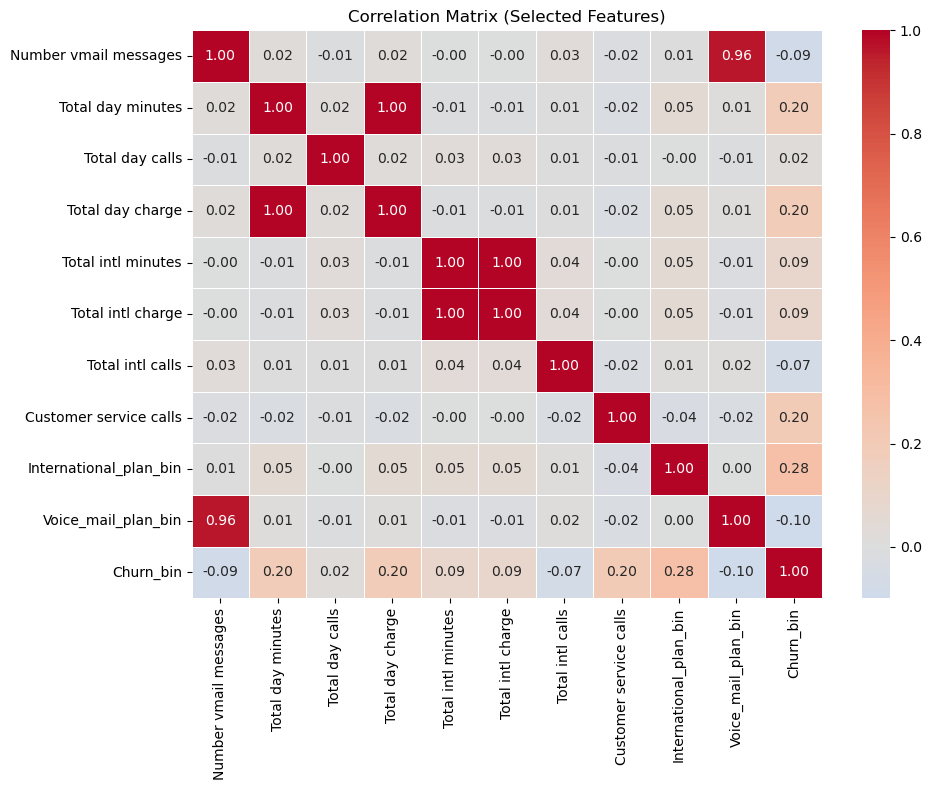

In [27]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # 상관계수 숫자 표시
    fmt=".2f",           # 소수점 2자리
    cmap='coolwarm',     # 색상
    center=0,            # 0 기준 색상 분리
    linewidths=0.5
)

plt.title('Correlation Matrix (Selected Features)')
plt.tight_layout()
plt.show()

Churn(Churn_bin)과의 상관관계를 살펴보면
1) International_plan_bin : 0.28
가장 높은 상관계수, 국제 요금제 사용 고객일수록 이탈 가능성 높다고 판단됨

2) Total day minutes / Total day charge : 0.20
낮 사용량/요금이 높을수록 이탈 가능성 높다고 판단됨

3) Customer service calls : 0.20
고객센터 문의 횟수가 높을수록 이탈 가능성 높다고 판단됨

4) Total intl minutes / Total intl charge : 0.09
약한 상관관계를 보임

5) Voice_mail_plan_bin : -0.10
음의 상관관계를 보임
음성사서함 요금제를 사용할수록 이탈 가능성 적음

6) Number vmail messages : -0.09
음의 상관관계를 보임
음성사서함 요금제 사용 여부와 같이 보면 좋을 것 같음
음성사서함 메세지가 많을수록 이탈 가능성 적음

7) Total intl calls : 0.07
상관관계가 낮은 편

8) Total day calls : 0.02
상관관계가 가장 낮음



**강한 상관 관계**
Total day charge - Total day minutes (1)
Total intl charge - Total intl minutes (1)
Voice_mail_plan_bin - Number vmail messages (0.96)

다중공선성 확인

위의 상관관계 히트맵을 통해서

Total day charge - Total day minutes : 1
Total intl charge - Total intl minutes : 1
Voice_mail_plan_bin - Number vmail messages : 0.96

세쌍의 값이 강한 상관관계가 있음을 알 수 있습니다.


이를 통해 각각의 쌍에서 하나를 제거하는게 좋을 것 같다고 판단함
1)  요금(charge)과 사용시간(minutes) 중에서 사용시간으로 인해 요금이 측정된다고 생각하여
요금을 제거하기로 결정함

2) 음성사서함 가입 여부와 음성사서함 메세지 수 중에서 음성사서함을 가입해야 메세지수가 생기기때문에 메세지 수를 제거하기로 결정함


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

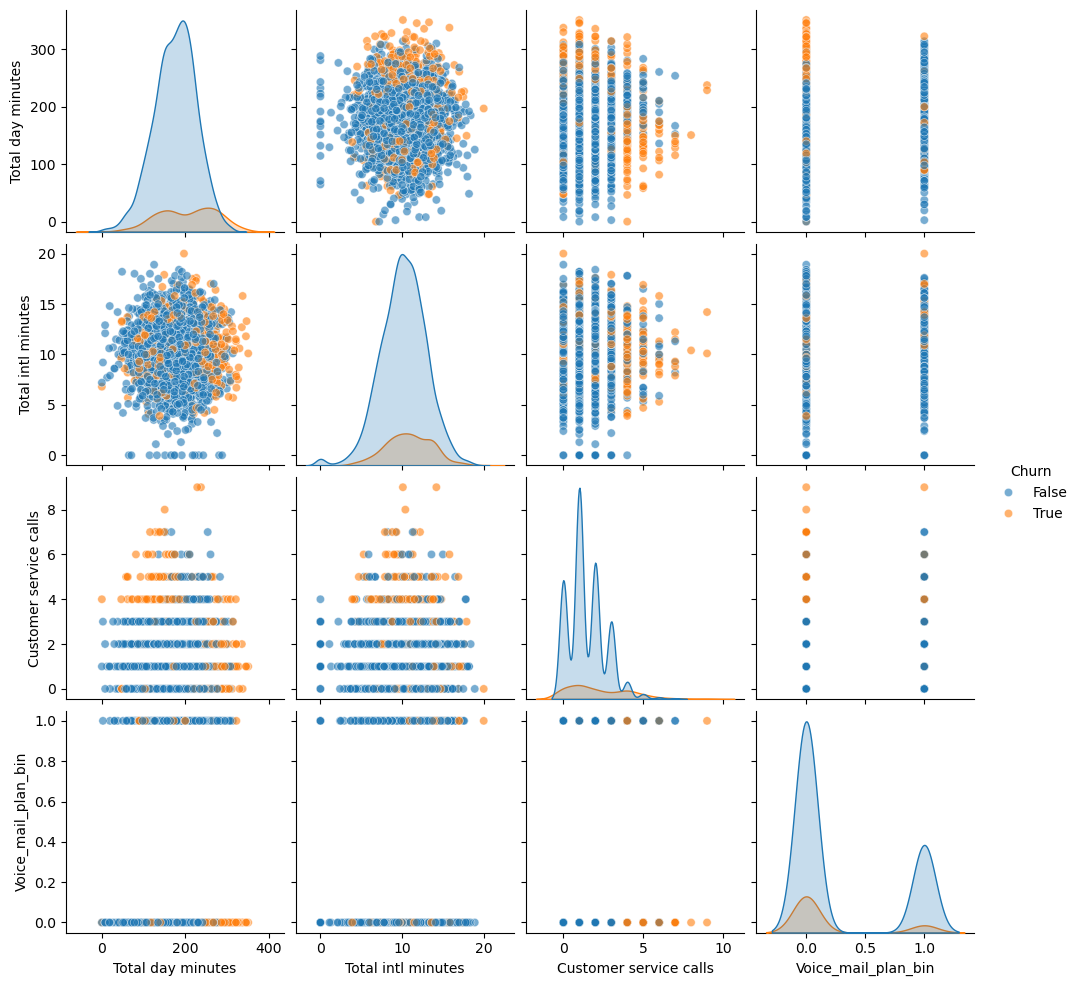

In [28]:
#Pair plot으로 변수 간 관계 시각화

pair_cols = [
    'Total day minutes',
    'Total intl minutes',
    'Customer service calls',
    'Voice_mail_plan_bin',
    'Churn'
]

sns.pairplot(
    df[pair_cols],
    hue='Churn',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

1) Customer service calls, Voice_mail_plan_bin
-> 고객센터 문의 많으면서 음성사서함 요금제 사용안하면 이탈 가능성 높음

2) Total day minutes, Voice_mail_plan_bin
-> 주간 통화시간이 많으면서 음성사서함 요금제 사용안하면 이탈 가능성 높음

In [29]:
#PCA를 통한 차원 축소 및 주요 성분 해석

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pca_cols = [
    'Total day minutes',
    'Total intl minutes',
    'Customer service calls',
    'Voice_mail_plan_bin'
]


# 1. 데이터 선택
X = df[pca_cols]

# 2. 표준화 (PCA는 반드시 필요)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 수행
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. 설명 분산 비율
explained_var = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(pca_cols))],
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Variance': pca.explained_variance_ratio_.cumsum()
})

explained_var

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.260947,0.260947
1,PC2,0.250702,0.511649
2,PC3,0.246533,0.758181
3,PC4,0.241819,1.000000


모든 PC가 24~26%로 매우 균등

->

변수들 간 상관은 있지만 매우 강하지 않음

한 개의 **지배적인 패턴**이 없음

고객 이탈이 단일 요인이 아닌 복합적 행동 결과

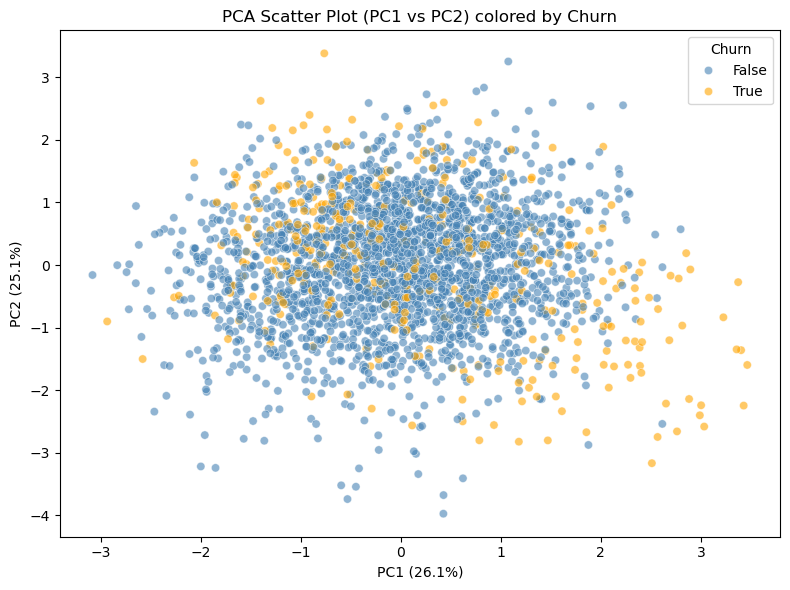

In [30]:


# PCA (PC1, PC2만 사용)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA 결과를 DataFrame으로 변환
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Churn'] = df['Churn'].values  # True / False 그대로 사용

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Churn',
    palette={False: 'steelblue', True: 'orange'},
    alpha=0.6
)

plt.title('PCA Scatter Plot (PC1 vs PC2) colored by Churn')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

pca는 개념이 아직 이해가 덜되고 어려워서 중도 포기..합니다..

**비즈니스 인사이트 도출**

- 이탈 고객의 주요 특징 3-5가지 정리

1) 고객센터 문의 횟수 많음

Churn=True 평균: 2.2회
Churn=False 평균: 1.45회

t-test 결과: p < 0.001

-> 불만이 누적된 고객일수록 이탈 가능성 높음

2) 국제전화 요금제 사용함

International plan = Yes → 이탈률 44%
International plan = No → 이탈률 11%

Chi-square 결과:

-> 요금 부담으로 인해 이탈 가능성 급증

3) 주간 통화시간 / 요금이 높음

Total day minutes / charge: Churn=True가 유의하게 더 높음

t-test 결과: p < 0.001

-> 주간 통화량/요금이 많은 고객이 이탈 가능성 높음

4) 음성 사서함(Voice mail plan) 가입자는 이탈률 낮음

Voice mail plan = Yes → 이탈률 9%
Voice mail plan = No → 이탈률 17%

Chi-square: p < 0.001

-> 서비스 락인 효과로 해당 서비스를 이용하면 이탈률이 낮다


- 지역별/요금제별 이탈률 차이 분석
State별 이탈률: 약 21% ~ 29% 범위

상위 5 / 하위 5로 나누었을 때 이탈률 : Chi-square test → 통계적으로 유의

요금제 별 이탈률
1) International plan
이탈률 차이 가장 큼

2) Voice mail plan
가입한 고객들 이탈률이 적음


- 고위험 고객 프로필 정의
1) International plan = Yes
2) Customer service calls >= 2
3) Voice mail plan = No
4) Total day minutes / Total intl minutes 높음

- EDA 결과를 바탕으로 가설 수립


가설1) 고객센터 문의 횟수는 이탈 가능성이 높다

가설2) 국제전화 요금제를 사용하는 고객은 요금 부담때문에 이탈 가능성이 높다

가설3) 음성사서함 요금제는 고객 락인 효과로 인하여 이탈률을 낮춘다

가설4) 통화를 많이 할수록 요금 부담때문에 이탈 가능성이 높다


EDA에서 가설을 세웠으므로 모델 학습을 통해 가설을 검증하고, 예측을 진행해보도록 하겠습니다.

# **4. 모델 학습**

**최소 2가지 이상 알고리즘 시도** 

**예시)**

- Logistic Regression
- Random Forest
- K-Nearest Neighbors

**교차 검증 (Cross-Validation)**

- K-Fold CV 수행
- 각 모델의 평균 성능 및 표준편차 기록
- Overfitting 여부 확인 (훈련 성능 vs 검증 성능 비교)

**하이퍼파라미터 튜닝**

- GridSearchCV 또는 RandomizedSearchCV 활용
- Random Forest: n_estimators, max_depth 등 다양한 하이퍼 파라미터 조정
- 최적 파라미터 조합 문서화

## 최소 2가지 이상 알고리즘 시도

- Logistic Regression
- Random Forest



In [31]:
# Logistic Regression

import statsmodels.api as sm
import numpy as np

# 가설 기반 설명변수 피쳐 선택
feature_cols = [
    "Customer service calls",
    "International plan",
    "Voice mail plan",
    "Total day minutes",
    "Total intl minutes",
]
X = df[feature_cols].copy()

# 타겟 변수
y = df["Churn"].map({True: 1, False: 0}).astype(int)

# 바이너리 값으로 변환
X["International plan"] = X["International plan"].map({"Yes": 1, "No": 0}).astype(int)
X["Voice mail plan"] = X["Voice mail plan"].map({"Yes": 1, "No": 0}).astype(int)

# 5) 절편값 추가 / 모든 변수가 0일때의 churn 기준 로그 오즈(log-odds)를 의미하며, 이를 통해 기본 churn 확률을 계산할 수 있음
X_sm = sm.add_constant(X)

# 6) 가설 검정을 위한 로지스틱 회귀 모형을 정의
# 로지스틱 회귀 계수(β)값들을 최대우도추정(MLE) 방식으로 추정함
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit(disp=True) 

print(result.summary())

# 7) 로지스틱 회귀로 추정한 β 값들을 오즈비(Odds Ratio)로 변환하고  + p-value 테이블
# 로지스틱 회귀로 추정된 회귀 계수 β 값을 가져옴
params = result.params
# 각 β값의 신뢰구간을 가져옴
conf = result.conf_int()
# β값을 오즈비로 변환함
odds_ratio = np.exp(params)
# β 신뢰구간을 오즈비 신뢰구간으로 변환
conf_odds = np.exp(conf)


summary_table = pd.DataFrame({
    "coef": params, #추정된 β 값
    "odds_ratio": odds_ratio, #오즈비(효과 크기)
    "p_value": result.pvalues, #가설 검정 결과
    "OR_2.5%": conf_odds[0], #오즈비(odds ratio) 95% 신뢰구간의 최소값(하한)
    "OR_97.5%": conf_odds[1], #오즈비(odds ratio) 95% 신뢰구간의 최대값(상한)
}).sort_values("p_value")

print("\n[Odds Ratio & p-values]")
print(summary_table)

Optimization terminated successfully.
         Current function value: 0.333293
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 2666
Model:                          Logit   Df Residuals:                     2660
Method:                           MLE   Df Model:                            5
Date:                Tue, 03 Feb 2026   Pseudo R-squ.:                  0.1967
Time:                        17:36:59   Log-Likelihood:                -888.56
converged:                       True   LL-Null:                       -1106.1
Covariance Type:            nonrobust   LLR p-value:                 8.187e-92
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -6.1134      0.378    -16.159      0.000      -6.855      

로지스틱 회귀 최적화가 문제 없이 수렴했으며, 평균 로그 손실은 0.333으로 비교적 낮고, 7번의 반복만에 안정적인 해를 찾았다.


로지스틱 회귀는 여러 설명변수를 이용해, 어떤 사건이 일어날 ‘확률’을 모델링하는 방법
로지스틱 회귀는 **“이 계수들이 가장 그럴듯한가?”**를 기준으로 학습함
지금 데이터가 실제로 이렇게 나왔다면,
이 계수 조합이 가장 그럴 법한 설명인가?”
이걸 우도(likelihood) 라고 함 모델은 log-likelihood를 최대화

Log-Likelihood는 “무엇을 측정하는 값”인가
현재 모델이 관측된 데이터(실제 churn 결과)를 얼마나 그럴듯하게 설명하는가
그 확률을 로그로 바꾼 값

ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ

Null model (절편만)	-1106.1
Full model (변수 포함)	-888.56

ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ


변수를 추가했더니 데이터 설명력이 훨씬 좋아짐 (−1106 → −888)

비교 대상은 두 개의 모델임(LLR 검정은 항상 두 모델을 비교합니다.)

1) Null model
절편만 있음
모든 사람에게 같은 churn 확률을 줌 “아무 정보도 안 쓰는 모델”

2) Full model
고객센터 전화 수, 국제요금제 등 모든 변수 포함
사람마다 다른 churn 확률을 예측

Q. “변수들을 추가한 게 정말 도움이 됐나?”

귀무가설(H₀)은 무엇인가?
H₀: 모든 계수 = 0 (즉, 변수들이 churn과 아무 관련이 없다)
-> 변수 써봤자 소용없다. Null model이면 충분하다

이때, **LLR p-value = 8.187e-92** 거의 0에 가까움
귀무가설이 맞다고 가정했을 때, 지금처럼 모델이 좋아질 확률은 거의 0임
-> 귀무가설(모든 계수 = 0)을 강하게 기각

결론 : 이 변수들은 churn과 구조적으로 관계가 있다
모델 전체는 통계적으로 매우 유의하다.


Pseudo R²은 '아무 변수도 안 쓴 모델에 비해, 이 모델은 얼마나 더 데이터를 잘 설명하는가?'를 물어봄(상대적인 개선 정도)
Null model → “모두 평균 확률” / Full model → “개인별 다른 확률”
Full model이 훨씬 덜 음수 즉, 데이터 설명이 훨씬 잘 됨

Pseudo R² = 0.1967
아무 정보도 없이 churn을 예측하던 모델에 비해, 지금 이 로지스틱 회귀 모델은 **약 19.7%**만큼 설명력을 개선했다

즉, LLR p-value ≈ 0를 통해 통계적으로 의미 있음을 알 수 있고
Pseudo R² ≈ 0.2를 통해 설명력 측면에서 의미 있음을 알 수 있음


***따라서 “고객 이탈은 랜덤이 아니라, 이 변수들과 구조적으로 연결되어 있다”***



Odds ratio 해석의 핵심 규칙

OR > 1 → 이탈 확률 증가

OR < 1 → 이탈 확률 감소

OR = 1 → 영향 없음

신뢰구간이 1을 포함하지 않으면 통계적으로 유의



| 변수                         | Odds Ratio (OR) | 영향 방향         | 해석 (쉬운 설명)                                                                   |
| -------------------------- | --------------- | ------------- | ---------------------------------------------------------------------------- |
| **절편 (const)**             | 0.002           | 기준값           | 모든 설명변수가 0일 때의 기준 이탈 오즈이다. 해석 대상은 아니며 기준점 역할만 한다.                            |
| **International plan**     | **7.83**        | 이탈 위험 크게 증가 ↑ | 국제전화 요금제를 사용하는 고객은 사용하지 않는 고객보다 **이탈 오즈가 약 7.8배 높다**. 본 모델에서 가장 영향력이 큰 변수이다. |
| **Customer service calls** | **1.63**        | 이탈 위험 증가 ↑    | 고객센터 문의 횟수가 1회 증가할 때마다 **이탈 오즈가 약 63% 증가**한다. 고객 불만을 강하게 반영하는 변수이다.          |
| **Voice mail plan**        | **0.42**        | 이탈 위험 감소 ↓    | 음성 사서함 요금제가 있는 고객은 **이탈 오즈가 약 58% 감소**한다. 이탈을 줄이는 보호 요인이다.                   |
| **Total day minutes**      | 1.012           | 이탈 위험 소폭 증가 ↑ | 낮 시간 통화량이 1분 증가할 때 **이탈 오즈가 약 1.2% 증가**한다. 통계적으로는 유의하지만 효과 크기는 작다.           |
| **Total intl minutes**     | 1.10            | 이탈 위험 증가 ↑    | 국제 통화 시간이 1분 증가할 때 **이탈 오즈가 약 9.6% 증가**한다. 국제전화 요금제와 같은 방향의 영향을 가진다.         |



가장 중요한 변수
* International plan
* Customer service calls

이탈을 줄이는 변수
* Voice mail plan

통계적으로는 유의하지만 실질 효과는 작은 변수
* Total day minutes
* Total intl minutes

고객 이탈은 국제전화 요금제 사용 여부와 고객센터 문의 횟수에 가장 큰 영향을 받으며, 음성 사서함 요금제는 이탈을 줄이는 보호 요인으로 작용한다.


In [44]:
#Random Forest

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score
)


# 2) 가설 기반으로 피쳐 선택
feature_cols = [
    "Customer service calls",
    "International plan",
    "Voice mail plan",
    "Total day minutes",
    "Total intl minutes",
]

X = df[feature_cols].copy()

# 3) 타겟 변수
y = df["Churn"].map({True: 1, False: 0}).astype(int)


# 4) 바이너리값 변경
X["International plan"] = X["International plan"].map({"Yes": 1, "No": 0}).astype(int)
X["Voice mail plan"] = X["Voice mail plan"].map({"Yes": 1, "No": 0}).astype(int)


# 5) Train/Test split (churn 비율 유지: stratify)
# 전체 데이터의 25%를 시험지(test)로 떼어둠
# random_state=42 매번 같은 방식으로 나누기 위한 “시드(seed)
# stratify=y : train과 test에 들어가는 churn 비율을 원래 데이터와 같게 맞춘다
# stratify 없이 나누면 생길 수 있는 문제 train: churn 10% / test: churn 25%
# 학습은 '이탈이 거의 없는 세상'에서 하고 평가는 '이탈이 많은 세상'에서 할 수 있음
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 6) 랜덤 포레스트 모델 학습
rf = RandomForestClassifier(
    n_estimators=400,          # 생성할 결정 트리 개수 (늘리면 안정적, 너무 크면 느림)
    max_depth=None,           # 깊이 제한 없음(기본). 과적합 우려 시 숫자로 제한
    min_samples_leaf=5,       # 리프 최소 샘플 수 5개 (과적합 overfitthing 완화) 
    random_state=42,          # 동일한 결과 재현을 위한 난수 설정
    class_weight="balanced"   # 클래스 불균형 보정: 소수 클래스(churn=1)에 더 큰 가중치를 부여하여 이탈 고객을 놓치는 오류(FN)를 더 크게 벌점 주고,
                              # 이탈 탐지(Recall)를 개선하도록 학습 유도
)
rf.fit(X_train, y_train)

# 7) Predict (label + probability)
# 테스트 데이터의 각 고객에 대해 최종 클래스(0 또는 1) 를 예측
y_pred = rf.predict(X_test)
# 각 고객이 churn(=1)일 확률(또는 확률처럼 해석되는 점수) 을 출력
y_prob = rf.predict_proba(X_test)[:, 1]
# y_pred는 “결정된 예측(분류 결과)” “이 고객을 이탈로 볼 것인가?” (Yes/No)
# y_prob는 “이탈 위험 점수” “이 고객이 얼마나 위험한가?” (0~1)


In [34]:
#랜덤 포레스트에 대해서 k-fold cv 수행함

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "f1": "f1",
    "precision": "precision",
}

cv_result = cross_validate(
    rf, #랜덤 포레스트 모델
    X, 
    y, # 전체 데이터
    cv=cv, # 5-fold를 만족하는 k-fold 4개 학습, 1개 검증 이 과정을 5번 반복
    scoring=scoring, #여러 성능 지표
    return_train_score=True
)

# 요약 출력
for metric in scoring:
    print(
        f"{metric:10s} | "
        f"train mean={cv_result[f'train_{metric}'].mean():.3f}, "
        f"val mean={cv_result[f'test_{metric}'].mean():.3f}, "
        f"val std={cv_result[f'test_{metric}'].std():.3f}"
    )

roc_auc    | train mean=0.976, val mean=0.884, val std=0.019
pr_auc     | train mean=0.882, val mean=0.702, val std=0.052
recall     | train mean=0.872, val mean=0.716, val std=0.035
f1         | train mean=0.768, val mean=0.632, val std=0.019
precision  | train mean=0.686, val mean=0.567, val std=0.029


roc_auc    | train mean=0.976, val mean=0.884, val std=0.019
이탈 고객과 유지 고객을 얼마나 잘 구분하는지
val ROC-AUC = 0.884 → 매우 우수
std = 0.019 → fold별 성능이 안정적
하지만 train과 val 차이(≈0.09) 존재
→ 과적합 신호

pr_auc     | train mean=0.882, val mean=0.702, val std=0.052
이탈 고객(소수 클래스)을 얼마나 위쪽에 잘 모아두었는지
불균형 데이터에서 중요
val PR-AUC = 0.702 → churn 문제에서 상당히 좋음
std = 0.052 → ROC-AUC보다 변동성 큼
train–val 차이 큼 → 과적합 영향이 PR에서 더 민감하게 드러남

이탈 고객 집중도는 높으나, fold에 따라 성능 변동이 있음


recall     | train mean=0.872, val mean=0.716, val std=0.035
실제 이탈 고객 중 얼마나 놓치지 않았는가
val Recall ≈ 0.72

→ 실제 이탈 고객의 약 72% 포착

std = 0.035 → 비교적 안정


f1         | train mean=0.768, val mean=0.632, val std=0.019
Precision과 Recall의 균형
val F1 ≈ 0.63

churn 예측에서 꽤 양호한 수준

train 대비 낮음 → 과적합 영향

precision  | train mean=0.686, val mean=0.567, val std=0.029
이탈로 예측한 고객 중 실제 이탈 비율
val Precision ≈ 0.57

→ 이탈로 찍은 고객 중 절반 이상은 실제 이탈

recall과의 trade-off 정상


Q. 이 결과로 과적합을 확인할 수 있는가?
네, 있습니다. (하지만 “치명적”은 아님)


모든 지표에서 train > val
ROC-AUC gap ≈ 0.09
PR-AUC gap ≈ 0.18

-> 모델이 학습 데이터 패턴을 꽤 많이 학습

하지만:
val 성능 자체가 높음
std가 과도하게 크지 않음

결론: “강한 모델이지만, 약간 날카롭다”

## 하이퍼파라미터 튜닝
RandomizedSearchCV 선택.

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# --- CV 설정 (불균형 데이터 → StratifiedKFold 권장)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 기본 RF 모델
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# --- 탐색 공간(과적합 완화 중심)
param_dist = {
    "n_estimators": [200, 300, 400, 600, 800],
    "max_depth": [None, 5, 8, 10, 12, 16],
    "min_samples_leaf": [1, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5, 0.7],
    "bootstrap": [True, False]
}

# --- RandomizedSearchCV
# churn 불균형이면 PR-AUC(average_precision)도 중요합니다.
# 1) 우선 ROC-AUC 기준으로 찾고
# 2) 상위 후보 중 PR-AUC도 확인하는 방식이 깔끔합니다.
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=40,                  # 20~60 권장(시간/성능 균형)
    scoring="roc_auc",          # 1차 기준
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_search.fit(X, y)

print("Best CV ROC-AUC:", rf_search.best_score_)
print("Best Params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV ROC-AUC: 0.8876230034023557
Best Params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.7, 'max_depth': 5, 'bootstrap': True}


RandomizedSearchCV를 통해 과적합을 강하게 억제한 Random Forest 구조를 선택했고,
그 결과 5-Fold CV 평균 ROC-AUC 0.888을 달성하였다.

탐색 규모: 40개 후보 × 5-Fold = 200번 학습

기준 지표: ROC-AUC

결과: Best CV ROC-AUC = 0.8876

📌 이전 RF CV val ROC-AUC ≈ 0.884
→ 소폭 개선 + 구조는 훨씬 안정적

## 하이퍼 파라미터 조정


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# --- 0) RandomizedSearchCV에서 얻은 최적 파라미터(사용자 결과)
best_params = {
    "n_estimators": 800,
    "min_samples_split": 5,
    "min_samples_leaf": 10,
    "max_features": 0.7,
    "max_depth": 5,
    "bootstrap": True
}

# --- 1) CV 설정 (불균형 데이터 → Stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 2) 기본 모델(고정할 값 포함)
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# --- 3) best_params를 "기준점"으로 주변 탐색 범위(미세조정용)
param_grid = {
    # 트리 수: 큰 폭보다는 주변값만
    "n_estimators": [best_params["n_estimators"] - 200, best_params["n_estimators"], best_params["n_estimators"] + 200],

    # 깊이: 과적합에 민감하므로 근처를 촘촘히
    "max_depth": [best_params["max_depth"] - 1, best_params["max_depth"], best_params["max_depth"] + 1],

    # leaf: 안정성/과적합에 중요
    "min_samples_leaf": [max(1, best_params["min_samples_leaf"] - 2), best_params["min_samples_leaf"], best_params["min_samples_leaf"] + 2],

    # split: 근처만 확인
    "min_samples_split": [best_params["min_samples_split"], best_params["min_samples_split"] + 5],

    # max_features: 비율 주변으로 미세조정
    "max_features": [0.6, best_params["max_features"], 0.8],

    # bootstrap은 best 결과 그대로 고정(변수 줄여서 효율↑)
    "bootstrap": [best_params["bootstrap"]],
}

# --- 4) GridSearchCV 실행 (1차는 ROC-AUC 기준 추천)
grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid.fit(X, y)

print("\n[GridSearch Result]")
print("Best CV ROC-AUC:", grid.best_score_)
print("Best Params:", grid.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

[GridSearch Result]
Best CV ROC-AUC: 0.8894382950607647
Best Params: {'bootstrap': True, 'max_depth': 5, 'max_features': 0.8, 'min_samples_leaf': 10, 'min_samples_split': 5, 'n_estimators': 600}


이 조합이 “최적”인 이유

얕은 트리 (max_depth = 5)
→ 과적합 억제

큰 리프 (min_samples_leaf = 10)
→ 노이즈 규칙 제거

트리 수 충분 (n_estimators = 600)
→ 안정성 확보

특성 사용 비율 80% (max_features = 0.8)
→ 트리 다양성과 정보 활용의 균형

bootstrap = True
→ 랜덤 포레스트 기본 구조 유지

👉 “단순한 트리를 많이 모은 안정적인 포레스트”


In [36]:
# 바로 사용할 최종 Random Forest 모델 코드
# 최적 파라미터 조합
from sklearn.ensemble import RandomForestClassifier

final_rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=5,
    max_features=0.8,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

,n_estimators,600
,criterion,'gini'
,max_depth,5
,min_samples_split,5
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,0.8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 5. 모델 평가

* Confusion Matrix & TP/TN/FP/FN
* Accuracy / Precision / Recall / F1-score 계산
* ROC Curve & AUC 스코어
* Precision-Recall Curve & PR-AUC 


Confusion Matrix:
 [[470 100]
 [ 25  72]]
TN=470, FP=100, FN=25, TP=72

[Threshold=0.5 Metrics]
Accuracy : 0.8126
Precision: 0.4186
Recall   : 0.7423
F1-score : 0.5353

Classification Report:
              precision    recall  f1-score   support

           0     0.9495    0.8246    0.8826       570
           1     0.4186    0.7423    0.5353        97

    accuracy                         0.8126       667
   macro avg     0.6840    0.7834    0.7090       667
weighted avg     0.8723    0.8126    0.8321       667


ROC-AUC: 0.8439


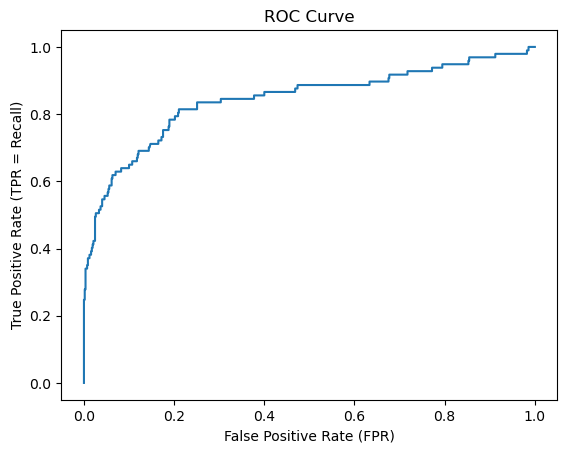

PR-AUC (Average Precision): 0.6723


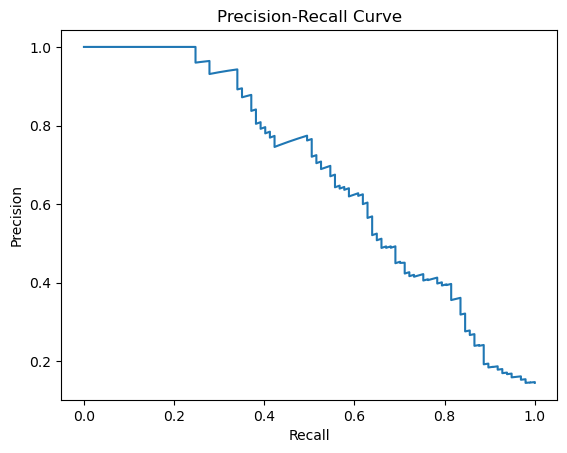

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    classification_report,
)

# ===== 0) 최적 파라미터로 최종 모델 정의 =====
final_rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=5,
    max_features=0.8,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ===== 1) 학습 =====
final_rf.fit(X_train, y_train)

# ===== 2) 예측 (라벨 + 확률) =====
y_prob = final_rf.predict_proba(X_test)[:, 1]   # churn(1) 확률
y_pred = (y_prob >= 0.5).astype(int)            # threshold=0.5 기준 라벨

# ===== 3) Confusion Matrix & TP/TN/FP/FN =====
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:\n", cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# ===== 4) Accuracy / Precision / Recall / F1 =====
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n[Threshold=0.5 Metrics]")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# ===== 5) ROC Curve & AUC =====
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR = Recall)")
plt.title("ROC Curve")
plt.show()

# ===== 6) Precision-Recall Curve & PR-AUC =====
pr_auc = average_precision_score(y_test, y_prob)
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_test, y_prob)

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

plt.figure()
plt.plot(recall_arr, precision_arr)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

| 구분       | 의미      | 해석                  |
| -------- | ------- | ------------------- |
| TN = 470 | 유지 → 유지 | 정상 고객 대부분을 잘 유지로 분류 |
| FP = 100 | 유지 → 이탈 | 유지 고객 100명을 이탈로 오탐  |
| FN = 25  | 이탈 → 유지 | 이탈 고객 25명을 놓침       |
| TP = 72  | 이탈 → 이탈 | 이탈 고객 72명 정확히 탐지    |

이탈 고객 97명 중 72명 포착 → Recall ≈ 74%
-> churn 문제에서 FN(놓친 이탈) 이 비교적 적다는 점은 매우 긍정적입니다
* Recall = TP / (TP + FN) : 실제 이탈 고객을 얼마나 놓치지 않고 탐지했는지를 나타내는 지표

이탈이라고 예측된 고객 중 약 42%만 실제 이탈 -> Precision ≈ 0.42
* Precision = TP / (TP + FP) : 이탈이라고 찍은 사람들 중에서, 진짜 이탈은 얼마나 되는가?

전체의 82%를 맞췄다
* Accuracy = (TP + TN) / (TP + TN + FP + FN) : 전체 고객 중에서, 맞춘 비율은 얼마인가

F1 ≈ 0.54
* F1 = 2 × (Precision × Recall) / (Precision + Recall) : 놓치지도 않고(Recall), 헛수고도 줄인(Precision) 균형 점수


Precision–Recall Trade-off (중요!)
* Recall ↑ → Precision ↓
* Precision ↑ → Recall ↓

→ Threshold 조정으로 균형 선택. 비즈니스 전략에 따라 결정


ROC Curve
| 축                 | 의미                  |
| ----------------- | ------------------- |
| X축 (FPR)          | 유지 고객을 이탈로 잘못 찍은 비율 |
| Y축 (TPR = Recall) | 실제 이탈 고객을 맞춘 비율     |

ROC Curve 아래 면적 = AUC
임의로 고른 이탈 고객 1명과 유지 고객 1명을 비교했을 때, 모델이 이탈 고객에게 더 높은 점수를 줄 확률

ROC-AUC = 0.8439
이 모델은 이탈 고객과 유지 고객을 비교했을 때, **약 84.4%** 확률로 이탈 고객을 더 높은 위험도로 평가한다



ROC Curve 및 AUC 분석 결과, 최종 모델은 ROC-AUC 0.844를 기록하여 이탈 고객과 유지 고객을 효과적으로 구분함을 확인하였다


PR Curve는 ‘그래프’이고,
PR-AUC는 그 그래프를 ‘한 숫자로 요약한 값

PR Curve는 Threshold를 계속 바꿔가면서 Recall과 Precision의 관계를 그린 선 그래프
threshold를 1 → 0으로 바꾸며 Precision/Recall 쌍을 계산

PR Curve : 이탈 고객을 더 많이 잡으려 할수록, 정확도가 얼마나 희생되는가

| 축  | 의미                       |
| -- | ------------------------ |
| X축 | Recall (이탈 고객을 얼마나 잡았는가) |
| Y축 | Precision (이탈 예측의 정확도)   |


PR Curve 그 곡선 아래 면적이 PR-AUC (Average Precision)
PR-AUC :  Recall 전 구간에 걸친 평균 Precision

Curve는 ‘어디까지 쓸지’, AUC는 ‘얼마나 좋은지’를 말해준다

결론 :
1) PR Curve
“상위 20% 고객까지는 Precision이 높네”
“여기부터 비용이 커지네”

2) PR Curve
“상위 20% 고객까지는 Precision이 높네”
“여기부터 비용이 커지네”


당신 데이터의 base rate

이탈 고객 비율 ≈ 97 / 667 ≈ 0.145

랜덤 모델 PR-AUC ≈ 0.145
당신 모델 PR-AUC = 0.672

-> 랜덤 대비 약 4.6배 개선

PR-AUC 0.67은 ‘이탈 고객을 높은 정확도로 위에서부터 잘 정렬하는 모델’이라는 뜻



## 비지니스 관점 평가
FN 비용
FP 비용
최적 threshold 설정

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def find_best_threshold_by_cost(y_true, y_prob, fn_cost, fp_cost, thresholds=None):
    """
    비용(손실) 관점에서 threshold를 선택:
      total_cost = fn_cost * FN + fp_cost * FP
    """

    # threshold를 0.01~0.99까지 바꿔가며 매번 FN/FP 개수를 계산
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99) 

    rows = []

    # 비용 함수(total_cost) 를 만들어 비용이 최소인 threshold를 고릅니다.

    for th in thresholds:
        y_pred = (y_prob >= th).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        total_cost = fn_cost * fn + fp_cost * fp

        rows.append({
            "threshold": th,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "total_cost": total_cost,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "accuracy": accuracy_score(y_true, y_pred),
        })

    df = pd.DataFrame(rows).sort_values("total_cost", ascending=True).reset_index(drop=True)
    best = df.iloc[0]
    return best, df

# ====== 예시 비용 설정 (당신 비즈니스에 맞게 바꾸세요) ======
# FN_cost: 이탈을 놓쳤을 때 평균 손실 (예: 평균 CLV 손실 200달러)
# FP_cost: 불필요한 혜택 제공 비용 (예: 쿠폰/혜택 평균 20달러)
FN_COST = 200
FP_COST = 20

best_row, all_rows = find_best_threshold_by_cost(y_test, y_prob, FN_COST, FP_COST)

print("=== Best threshold (Cost-based) ===")
print(best_row[["threshold","total_cost","FN","FP","TP","TN","precision","recall","f1"]])

# 상위 10개 후보도 같이 보기
print("\n=== Top 10 thresholds by lowest cost ===")
print(all_rows.head(10)[["threshold","total_cost","FN","FP","precision","recall","f1"]])

=== Best threshold (Cost-based) ===
threshold        0.440000
total_cost    6000.000000
FN              18.000000
FP             120.000000
TP              79.000000
TN             450.000000
precision        0.396985
recall           0.814433
f1               0.533784
Name: 0, dtype: float64

=== Top 10 thresholds by lowest cost ===
   threshold  total_cost  FN   FP  precision    recall        f1
0       0.44        6000  18  120   0.396985  0.814433  0.533784
1       0.43        6080  18  124   0.389163  0.814433  0.526667
2       0.42        6080  18  124   0.389163  0.814433  0.526667
3       0.28        6120  16  146   0.356828  0.835052  0.500000
4       0.41        6140  18  127   0.383495  0.814433  0.521452
5       0.39        6160  18  128   0.381643  0.814433  0.519737
6       0.40        6160  18  128   0.381643  0.814433  0.519737
7       0.36        6200  18  130   0.377990  0.814433  0.516340
8       0.37        6200  18  130   0.377990  0.814433  0.516340
9       0.38  

Confusion Matrix의 두 가지 “돈이 새는” 경우

FN (False Negative): 실제로 이탈할 고객을 “유지”로 분류해서 놓침
→ 놓친 고객의 손실 (매출/CLV 손실, 재획득 비용 등)

FP (False Positive): 실제로는 유지할 고객에게 “이탈 위험”으로 분류해 혜택 제공
→ 불필요한 혜택 비용 (할인/쿠폰/콜센터/인센티브 비용)

따라서 threshold를 선택할 때는 보통:

총비용 = FN_cost × FN + FP_cost × FP
을 최소화하는 threshold를 고릅니다.

“비용비율”이 threshold에 어떻게 영향을 주나?

FN_cost가 커질수록(이탈 놓치면 큰 손해)
→ threshold를 낮춰 더 많은 고객을 “위험”으로 잡음
→ Recall↑, FP↑

FP_cost가 커질수록(혜택이 비싸면)
→ threshold를 높여 혜택 대상을 줄임
→ Precision↑, FN↑

즉, 비즈니스 목표가 ‘놓치지 않기’인지 ‘낭비 줄이기’인지에 따라 threshold가 달라지는 게 정상



## 최종 테스트
churn 20으로 최종 성능 평가



In [40]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

# =========================
# 0) 설정값
# =========================
TRAIN_PATH = "churn-bigml-80.csv"
TEST_PATH  = "churn-bigml-20.csv"

FEATURES = [
    "Customer service calls",
    "International plan",
    "Voice mail plan",
    "Total day minutes",
    "Total intl minutes"
]
TARGET = "Churn"

OPTIMAL_THRESHOLD = 0.44  # 비용 기반으로 찾은 최적 threshold

FINAL_RF_PARAMS = dict(
    n_estimators=600,
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=5,
    max_features=0.8,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# =========================
# 1) 전처리 함수
#   - Yes/No -> 1/0
#   - True/False -> 1/0
#   - 숫자형 캐스팅
#   - 결측치 검사
# =========================
def _map_binary(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        "1": 1, "0": 0,
        "y": 1, "n": 0
    }
    return s.map(mapping)

def preprocess(df: pd.DataFrame, features, target=None):
    df = df.copy()

    # (A) 이진형 컬럼 매핑
    for col in ["International plan", "Voice mail plan"]:
        if col in df.columns:
            df[col] = _map_binary(df[col])

    # (B) 타겟 매핑
    if target is not None:
        df[target] = _map_binary(df[target])

    # (C) Feature/Target 분리
    X = df[features].copy()

    # 숫자형으로 변환 (문자형 숫자 포함)
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

    if target is not None:
        y = pd.to_numeric(df[target], errors="coerce")
        if y.isna().any():
            raise ValueError("[Preprocess Error] NaN found in target after mapping. Check Churn labels.")
        y = y.astype(int)
        return X, y

    return X

# =========================
# 2) 데이터 로드 + 전처리
# =========================
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# 컬럼 존재 확인(실수 방지)
for col in FEATURES + [TARGET]:
    if col not in train_df.columns:
        raise ValueError(f"[Column Error] '{col}' not found in churn-80.csv")
for col in FEATURES + [TARGET]:
    if col not in test_df.columns:
        raise ValueError(f"[Column Error] '{col}' not found in churn-20.csv")

X_train, y_train = preprocess(train_df, FEATURES, TARGET)
X_test,  y_test  = preprocess(test_df,  FEATURES, TARGET)

# =========================
# 3) 최종 모델 학습 (churn-80)
# =========================
final_rf = RandomForestClassifier(**FINAL_RF_PARAMS)
final_rf.fit(X_train, y_train)

# =========================
# 4) churn-20 최종 예측 (확률 + threshold=0.44)
# =========================
y_prob_test = final_rf.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= OPTIMAL_THRESHOLD).astype(int)

# =========================
# 5) Final Test 결과 출력
# =========================
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

print("=== FINAL TEST (churn-20) ===")
print(f"Threshold (business-optimal) = {OPTIMAL_THRESHOLD}")
print("\nConfusion Matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=4))

# Threshold-independent 성능(모델 구분 능력 확인)
roc_auc = roc_auc_score(y_test, y_prob_test)
pr_auc  = average_precision_score(y_test, y_prob_test)

print(f"\nROC-AUC (threshold-independent): {roc_auc:.4f}")
print(f"PR-AUC  (threshold-independent): {pr_auc:.4f}")

# =========================
# (선택) 0.5와 0.44 비교도 같이 보고 싶다면
# =========================
y_pred_05 = (y_prob_test >= 0.5).astype(int)
cm05 = confusion_matrix(y_test, y_pred_05)
tn05, fp05, fn05, tp05 = cm05.ravel()

print("\n=== Comparison (threshold=0.5 vs 0.44) ===")
print(f"0.5  -> TN={tn05}, FP={fp05}, FN={fn05}, TP={tp05}")
print(f"0.44 -> TN={tn},   FP={fp},   FN={fn},   TP={tp}")

=== FINAL TEST (churn-20) ===
Threshold (business-optimal) = 0.44

Confusion Matrix:
[[468 104]
 [ 16  79]]
TN=468, FP=104, FN=16, TP=79

Classification Report:
              precision    recall  f1-score   support

           0     0.9669    0.8182    0.8864       572
           1     0.4317    0.8316    0.5683        95

    accuracy                         0.8201       667
   macro avg     0.6993    0.8249    0.7274       667
weighted avg     0.8907    0.8201    0.8411       667


ROC-AUC (threshold-independent): 0.8812
PR-AUC  (threshold-independent): 0.7543

=== Comparison (threshold=0.5 vs 0.44) ===
0.5  -> TN=481, FP=91, FN=19, TP=76
0.44 -> TN=468,   FP=104,   FN=16,   TP=79


In [41]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score

# ===== 1) Train 성능 =====
train_prob = final_rf.predict_proba(X_train)[:, 1]
train_roc = roc_auc_score(y_train, train_prob)
train_pr  = average_precision_score(y_train, train_prob)

# ===== 2) Validation 성능 (CV 평균) =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

cv_res = cross_validate(
    final_rf, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

val_roc = cv_res["test_roc_auc"].mean()
val_pr  = cv_res["test_pr_auc"].mean()

# ===== 3) Final Test 성능 =====
test_prob = final_rf.predict_proba(X_test)[:, 1]
test_roc = roc_auc_score(y_test, test_prob)
test_pr  = average_precision_score(y_test, test_prob)

# ===== 4) 비교 출력 =====
print("=== Generalization Performance Check ===")
print(f"Train ROC-AUC: {train_roc:.4f} | PR-AUC: {train_pr:.4f}")
print(f"Valid ROC-AUC: {val_roc:.4f} | PR-AUC: {val_pr:.4f}")
print(f"Final ROC-AUC: {test_roc:.4f} | PR-AUC: {test_pr:.4f}")

=== Generalization Performance Check ===
Train ROC-AUC: 0.9232 | PR-AUC: 0.7828
Valid ROC-AUC: 0.8894 | PR-AUC: 0.7224
Final ROC-AUC: 0.8812 | PR-AUC: 0.7543


ROC-AUC / PR-AUC 변화
| 단계                        | ROC-AUC    | 변화      | PR-AUC     | 변화          |
| ------------------------- | ---------- | ------- | ---------- | ----------- |
| **Train**                 | 0.9232     | 기준      | 0.7828     | 기준          |
| **Validation (CV)**       | 0.8894     | −0.0338 | 0.7224     | −0.0604     |
| **Final Test (churn-20)** | **0.8812** | −0.0082 | **0.7543** | **+0.0319** |

수치 변화의 의미 (모델 관점)

* ROC-AUC

Train → Validation → Final로 완만한 감소

급격한 성능 하락 없음

과적합 신호 없음

모델의 구분 능력(discrimination) 이 안정적으로 유지됨

* PR-AUC (더 중요)

Validation 대비 Final Test에서 상승

이탈 고객(소수 클래스)에 대한 정렬 능력 개선

최종 테스트 데이터에서도 실제 타겟팅 품질이 높음



모델은 과적합 없이 일반화되었으며, 최종 테스트에서 이탈 고객 타겟팅 품질(PR-AUC)이 오히려 향상되어 비즈니스 적용에 매우 적합하다.


## 6. 모델 해석
### Feature importance 확인 및 분석


In [42]:
import pandas as pd

# =========================
# 1) Feature importance 추출
# =========================
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

print("=== Feature Importances ===")
print(importances)

=== Feature Importances ===
                  feature  importance
3       Total day minutes    0.376591
0  Customer service calls    0.271980
1      International plan    0.235637
4      Total intl minutes    0.058009
2         Voice mail plan    0.057783


### 중요변수 시각화

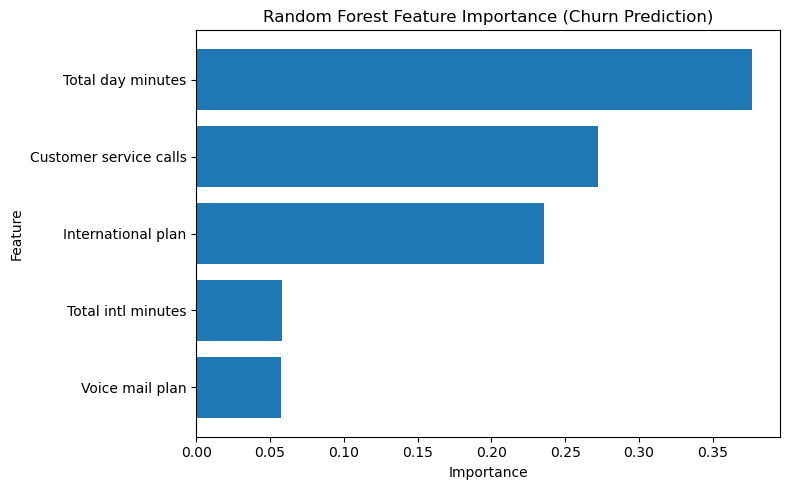

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(
    importances["feature"],
    importances["importance"]
)
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (Churn Prediction)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 변수별 기여도 비지니스 해석

| 변수명                        | 모델 중요도 | 방향성(해석)         | 비즈니스 의미                                              |
| -------------------------- | -----: | --------------- | ---------------------------------------------------- |
| **Total day minutes**      |  매우 높음 | 사용량 ↑ → 이탈 ↑    | 통화 사용량이 많은 고객일수록 요금 부담이 커지며, 가격 민감도가 높아져 이탈 가능성이 증가함 |
| **Customer service calls** |     높음 | 문의 횟수 ↑ → 이탈 ↑  | 잦은 고객센터 문의는 서비스 불만, 품질 이슈 또는 문제 미해결 상태를 나타내는 신호로 해석됨 |
| **International plan**     |     높음 | 가입 시 → 이탈 ↑     | 국제 요금제 사용 고객은 비용 부담과 요금 구조 복잡성으로 인해 이탈 위험이 상대적으로 높음  |
| **Total intl minutes**     |  중간~높음 | 국제 통화량 ↑ → 이탈 ↑ | 국제 통화 사용량이 많을수록 요금 증가로 인한 불만과 이탈 가능성이 커짐             |
| **Voice mail plan**        |     낮음 | 가입 시 → 이탈 ↓     | 부가서비스 사용 고객은 서비스 이용도가 높고, 락인 효과로 인해 이탈 가능성이 낮음       |


## 부분 의존성 플롯
### 특정 변수가 예측에 미치는 영향 시각화

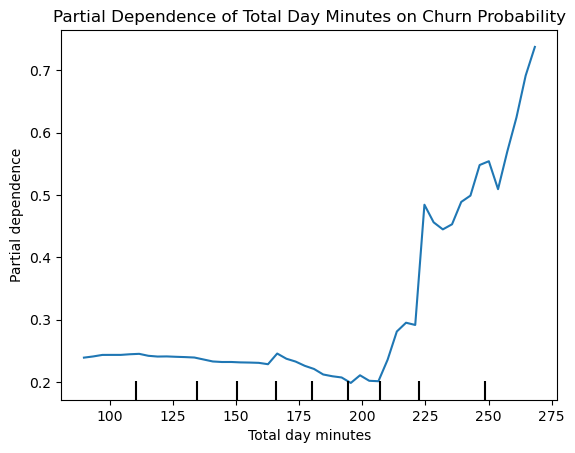

In [ ]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

#Total day minutes 
PartialDependenceDisplay.from_estimator(
    final_rf,           # 학습된 Random Forest
    X_train,            # 학습 데이터
    features=["Total day minutes"],
    kind="average",
    grid_resolution=50
)

plt.title("Partial Dependence of Total Day Minutes on Churn Probability")
plt.show()


c:\Users\mondd\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\mondd\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\mondd\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: Fu

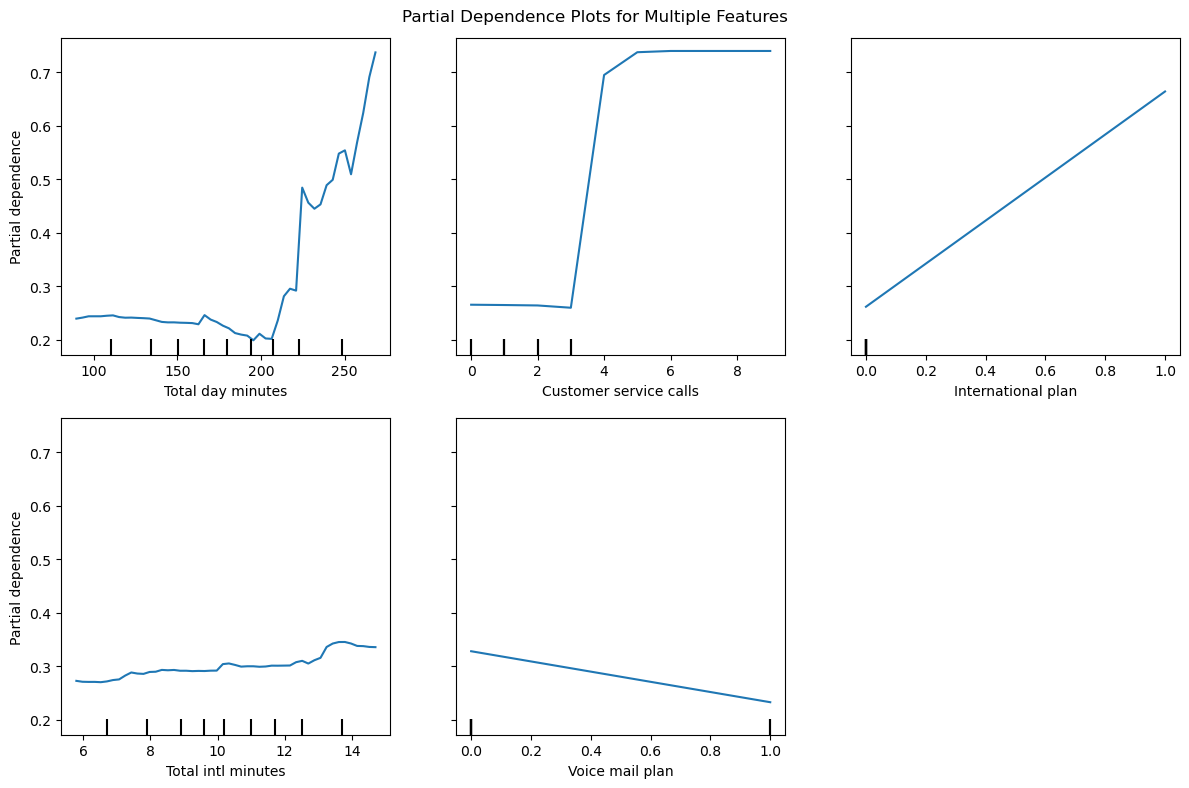

In [46]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = [
    "Total day minutes",
    "Customer service calls",
    "International plan",
    "Total intl minutes",
    "Voice mail plan"
]

fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    final_rf,        # 학습된 Random Forest 모델
    X_train,         # 학습 데이터
    features=features,
    kind="average",
    grid_resolution=50,
    ax=ax
)

plt.suptitle("Partial Dependence Plots for Multiple Features")
plt.tight_layout()
plt.show()

### 비선형성 관계 파악
Total day minutes / Customer service calls / Total intl minutes에서 비선형성 관계를 파악할 수 있었음



| 변수명                        | PDP 관찰 내용                            | 모델 관점 해석                | 비즈니스 해석                                                 |
| -------------------------- | ------------------------------------ | ----------------------- | ------------------------------------------------------- |
| **Total day minutes**      | 약 200분 이후 이탈 확률이 급격히 상승하며 비선형 패턴을 보임 | 명확한 임계점이 존재하는 강한 비선형 관계 | 일정 통화량을 초과하면 요금 부담을 크게 인식하며 이탈 위험이 급증함                  |
| **Customer service calls** | 0~2회까지는 안정적이나, 3회 이상에서 이탈 확률이 급격히 증가 | 불만 누적에 따른 임계값 효과        | 반복적인 고객센터 문의는 해결되지 않은 불만의 신호이며, 3회 이상부터 이탈 직전 상태로 해석 가능 |
| **International plan**     | 0 → 1로 전환 시 이탈 확률이 크게 점프             | 이진 변수지만 매우 강력한 분기 기준    | 국제 요금제 가입 여부 자체가 강한 이탈 신호이며 요금 민감도를 반영                  |
| **Total intl minutes**     | 완만한 우상향 곡선, 급격한 변화는 없음               | 보조적인 위험 요인              | 국제 통화량 증가는 점진적으로 이탈 위험을 높이나 단독 결정 요인은 아님                |
| **Voice mail plan**        | 0 → 1로 갈수록 이탈 확률 감소                  | 보호 변수(락인 효과)            | 부가서비스 사용은 서비스 이용도를 높여 이탈 가능성을 완화함                       |


### 상호 작용 효과 확인 2D PDP

c:\Users\mondd\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\mondd\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\mondd\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: Fu

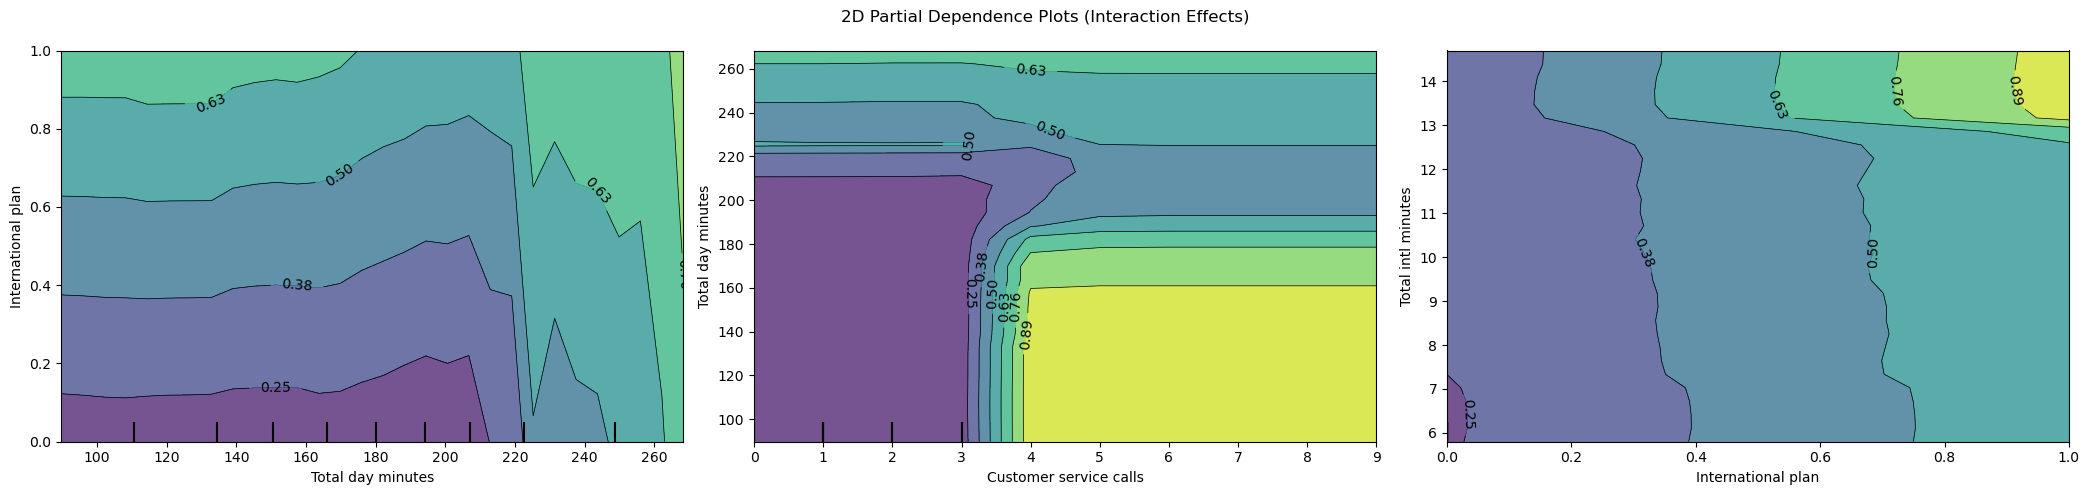

In [49]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 상호작용을 보고 싶은 변수 쌍
features_2d = [
    ("Total day minutes", "International plan"),
    ("Customer service calls", "Total day minutes"),
    ("International plan","Total intl minutes")
]

fig, ax = plt.subplots(1, 3, figsize=(21, 5))

PartialDependenceDisplay.from_estimator(
    final_rf,        # 학습된 Random Forest
    X_train,         # 학습 데이터
    features=features_2d,
    kind="average",
    grid_resolution=30,
    ax=ax
)

plt.suptitle("2D Partial Dependence Plots (Interaction Effects)")
plt.tight_layout()
plt.show()

| 패턴           | 의미        |
| ------------ | --------- |
| 단일 변수만 높을 때  | 이탈 위험 제한적 |
| 두 변수 이상 겹칠 때 | 이탈 확률 급증  |
| 국제 요금제       | 위험 증폭기 역할 |
| 고객센터 문의      | 이탈 임계 트리거 |


Feature Importance · 1D PDP와의 일관성

Feature Importance:
→ 사용량 · CS · 국제요금제 상위

1D PDP:
→ 각 변수에 임계점 존재

2D PDP:
→ 임계점들이 겹칠 때 폭발

2D Partial Dependence Plot 분석 결과, 통화 사용량, 고객센터 문의 횟수, 국제 요금제 간에 강한 상호작용 효과가 확인되었다. 특히 국제 요금제 사용 고객 중 고사용량 또는 반복적인 불만을 가진 고객에서 이탈 확률이 비선형적으로 증가하는 패턴이 관찰되었다

이탈은 ‘하나의 문제’가 아니라,
요금 부담·불만·요금제 조건이 겹칠 때 발생하는 누적 리스크의 결과다




## 오분류 케이스 분석
### False Positive / False Negative 추출

In [50]:
#False Positive / False Negative 추출

import pandas as pd
import numpy as np

# =========================
# 1) Threshold 적용
# =========================
threshold = 0.44
y_pred_custom = (y_prob >= threshold).astype(int)

# =========================
# 2) 결과 DataFrame 생성
# =========================
result_df = X_test.copy()
result_df["y_true"] = y_test.values
result_df["y_prob"] = y_prob
result_df["y_pred"] = y_pred_custom

# =========================
# 3) FP / FN 추출
# =========================
false_positive = result_df[
    (result_df["y_true"] == 0) & (result_df["y_pred"] == 1)
]

false_negative = result_df[
    (result_df["y_true"] == 1) & (result_df["y_pred"] == 0)
]

print("FP count:", len(false_positive))
print("FN count:", len(false_negative))

FP count: 95
FN count: 26


### 공통 특성 파악 및 모델 개선 방향 도출

* False Positive / False Negative 공통 특성

| 구분                     | False Positive (FP) | False Negative (FN) |
| ---------------------- | ------------------- | ------------------- |
| 정의                     | 실제 유지 고객을 이탈로 예측    | 실제 이탈 고객을 유지로 예측    |
| 건수                     | 95                  | 26                  |
| International plan     | 비중 높음               | 비중 낮음               |
| Total day minutes      | 높음 (고사용량)           | 보통~낮음               |
| Total intl minutes     | 상대적으로 높음            | 낮거나 보통              |
| Customer service calls | 낮거나 보통              | 낮음                  |
| 고객 특성 요약               | **비싸지만 만족하는 고객**    | **조용히 떠나는 고객**      |


* FP -> 모델은 ‘요금 부담’ 신호를 과대평가하고 있으며, ‘만족도/충성도’를 구분할 수 있는 정보가 부족하다.
* FN -> 현재 모델은 ‘가격·불만 중심의 이탈’에는 강하지만, ‘관계·경쟁·라이프사이클 기반 이탈’에는 약하다.

* 오분류에서 드러난 모델의 한계

| 구분          | 해석                      |
| ----------- | ----------------------- |
| FP 다수 발생 원인 | 요금/사용량 기반 위험 신호를 과대평가함  |
| FN 발생 원인    | 불만·사용량 외 이탈 요인을 포착하지 못함 |
| 모델의 강점      | 가격 부담·불만 기반 이탈 예측에는 강함  |
| 모델의 약점      | 만족도·충성도·경쟁 요인 반영 부족     |


* 모델 개선 방향 도출

| 관찰 결과            | 의미             | 개선 방향                              |
| ---------------- | -------------- | ---------------------------------- |
| 국제 요금제 가입자 FP 많음 | 요금제 자체 효과 과대평가 | 국제 요금제 세분화 변수 필요 (할인 여부, 실제 청구액 등) |
| 고사용량 FP 존재       | 고사용량 ≠ 이탈      | 장기 이용 여부, 충성도 변수 추가                |
| 불만·사용량 낮은 FN 존재  | 숨겨진 이탈 요인 존재   | 계약 만료, 요금제 변경 이력, 경쟁사 이동 신호 추가     |
| 특정 고객군에서 오분류 집중  | 고객군별 행동 패턴 상이  | 고객군별 threshold 또는 정책 차등 적용         |



# 7. 비지니스 인사이트 및 액션 플랜

## **이탈 주요 원인 정리**

* 요금/사용량 부담(특히 Total day minutes): PDP에서 임계점 이후 급상승

* 불만 신호(Customer service calls): 문의 3회 이후 급격히 증가

* 국제요금제(International plan): 단독으로도 이탈 확률 점프 + 다른 요인 증폭(2D PDP)

* 부가서비스(Voice mail plan): 보호 요인(락인 효과)


## 고위험 고객 세그먼트 정의

| 기준    | 조건                                                 |
| ----- | -------------------------------------------------- |
| 모델 기준 | 예측 이탈 확률 ≥ **0.44**                                |
| 요금 부담 | Total day minutes 상위 25% 또는 International plan = 1 |
| 불만 신호 | Customer service calls ≥ 2                         |
| 락인 여부 | Voice mail plan = 0                                |

-> 이 중 2개 이상 만족 시 High-risk
* 모델 확률 → “정량적 위험”
* 사용량 / 요금제 → “요금 부담”
* CS calls → “불만 누적”
* Voice mail plan → “락인 부재”

이 4가지는
Feature Importance 상위 / PDP에서 임계점 확인 / 오분류 분석에서 반복 등장

High-risk 고객은 모델 예측 이탈 확률이 높고, 동시에 요금 부담 또는 서비스 불만과 같은 명확한 위험 신호를 보이는 고객으로 정의하였다


### 예상 이탈률 및 모델 예측 신뢰도 제시

In [51]:
expected_churn_rate_overall = y_test.mean()
print(expected_churn_rate_overall)

0.1454272863568216


In [52]:
expected_churn_rate_target = y_test[y_pred == 1].mean()
print(expected_churn_rate_target)

0.4861111111111111


아무것도 하지 않으면, 전체 고객 중 약 XX%가 이탈한다
모델이 ‘이탈 위험’이라고 찍은 고객 중, 실제로 이탈하는 고객의 비율

전체 이탈률: 14%

타겟군 이탈률: 42%

👉 타겟팅 효율이 3배 높음

In [53]:
summary = pd.DataFrame({
    "Metric": [
        "Overall churn rate",
        "Targeted churn rate (Expected)",
        "Precision (Prediction reliability)",
        "Recall (Churn capture rate)",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        y_test.mean(),
        y_test[y_pred == 1].mean(),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob)
    ]
})

print(summary.round(4))

                               Metric   Value
0                  Overall churn rate  0.1454
1      Targeted churn rate (Expected)  0.4861
2  Precision (Prediction reliability)  0.4861
3         Recall (Churn capture rate)  0.7216
4                             ROC-AUC  0.8411
5                              PR-AUC  0.6425


| 지표                  |          값 | 의미                |
| ------------------- | ---------: | ----------------- |
| Precision           | **0.4861** | 타겟 2명 중 1명은 실제 이탈 |
| Targeted churn rate | **0.4861** | 타겟군 집중도 3.3배      |
| PR-AUC              | **0.6425** | 위험 순위 신뢰 가능       |
| Recall              |     0.7216 | 이탈의 72% 포착        |


Model prediction reliability는 Precision으로 측정되며, 본 모델은 약 48.6%의 Precision을 보여 타겟 고객 중 실제 이탈 비율이 크게 증가함을 확인하였다

### 실행가능한 비지니스 전략


| 전략 영역              | 타겟 고객 세그먼트                             | 핵심 근거 (모델 인사이트)                             | 실행 전략                          | 
| ------------------ | -------------------------------------- | ------------------------------------------- | ------------------------------ | 
| **국제 요금제 최적화**     | International plan = 1 & y_prob ≥ 0.44 | 국제 요금제는 단독·상호작용 모두에서 강한 이탈 신호 (PDP, 2D PDP) | 요금 구조 단순화, 국제 통화 할인 | 
| **고사용량 고객 관리**     | Total day minutes 상위 구간                | 사용량 임계점 이후 이탈 확률 급증 (비선형 PDP)               | 무제한/상위 요금제 제안       | 
| **불만 누적 고객 케어** | Customer service calls ≥ 2             | 문의 3회 이상부터 이탈 급증 (PDP)                      | 사전 케어, 문제 해결 전담 TF           | 
| **락인 강화 전략**       | Voice mail plan = 0 & 중위험군             | 부가서비스는 이탈 완화 효과 (PDP)                       | 해당 서비스 무료체험 제공                     | 


In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score

def roi_retention_vs_acquisition(
    y_true,
    y_prob,
    threshold=0.44,
    retention_cost_per_target=15,   # 리텐션 오퍼/콜/쿠폰 등 1인당 비용
    acquisition_cost_per_customer=120,  # 신규 고객 1명 확보 비용(CAC)
    value_per_saved_customer=200,   # 이탈 방지 1명당 기대 이익(마진/CLV 등)
    uplift_success=0.20,            # 타겟에게 오퍼했을 때 실제 이탈이 방지되는 확률(10~30% 민감도 권장)
    name="Scenario"
):
    """
    y_true: 실제 이탈(1)/유지(0)
    y_prob: 모델 예측 이탈 확률
    threshold: 타겟 분류 기준 (비용 기반 최적 threshold 사용 권장)
    uplift_success: 개입이 실제로 이탈을 '방지'하는 비율(=uplift). 실무에선 실험(A/B)로 추정.
    """

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision = precision_score(y_true, y_pred, zero_division=0)  # 타겟(예측1) 중 실제 이탈 비율
    recall = recall_score(y_true, y_pred, zero_division=0)

    n_total = len(y_true)
    n_target = int((y_pred == 1).sum())
    base_churn_rate = float(np.mean(y_true))

    # (1) 타겟 고객군에서 "기대 이탈 수"
    #   = 타겟수 * 타겟군 실제 이탈 비율(precision)
    expected_churn_in_target = n_target * precision

    # (2) 오퍼로 인해 실제로 "방지되는 이탈 수" (uplift 기반)
    prevented_churn = expected_churn_in_target * uplift_success

    # (3) 투자 비용(리텐션 비용)
    retention_spend = n_target * retention_cost_per_target

    # (4) 이익 개선: 이탈 방지 가치(마진/CLV)
    profit_uplift = prevented_churn * value_per_saved_customer

    # (5) 비용 절감: 이탈 방지로 인해 신규 고객을 그만큼 덜 확보해도 된다고 보면 CAC 절감
    saved_acq_cost = prevented_churn * acquisition_cost_per_customer

    # (6) 총 효과 & ROI
    total_benefit = profit_uplift + saved_acq_cost
    net_benefit = total_benefit - retention_spend
    roi = net_benefit / retention_spend if retention_spend > 0 else np.nan

    out = pd.DataFrame([{
        "Scenario": name,
        "threshold": threshold,
        "n_total": n_total,
        "base_churn_rate": base_churn_rate,
        "n_target": n_target,
        "precision(target_churn_rate)": precision,
        "recall": recall,
        "expected_churn_in_target": expected_churn_in_target,
        "uplift_success": uplift_success,
        "prevented_churn": prevented_churn,
        "retention_cost_per_target": retention_cost_per_target,
        "retention_spend": retention_spend,
        "value_per_saved_customer": value_per_saved_customer,
        "profit_uplift": profit_uplift,
        "acquisition_cost_per_customer": acquisition_cost_per_customer,
        "saved_acq_cost": saved_acq_cost,
        "total_benefit": total_benefit,
        "net_benefit": net_benefit,
        "ROI": roi,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    }])

    return out


# =========================
# 사용 예시
# =========================
# y_test: 실제 라벨(0/1)
# y_prob_test: 예측확률
# 당신이 계산한 값(precision≈0.4861 등)이 그대로 반영됨

roi_result = roi_retention_vs_acquisition(
    y_true=y_test.values,
    y_prob=y_prob_test,
    threshold=0.44,
    retention_cost_per_target=15,
    acquisition_cost_per_customer=120,
    value_per_saved_customer=200,
    uplift_success=0.20,  # 0.10~0.30 시나리오 비교 권장
    name="Base ROI"
)

print(roi_result.round(2))

   Scenario  threshold  n_total  base_churn_rate  n_target  \
0  Base ROI       0.44      667             0.15       183   

   precision(target_churn_rate)  recall  expected_churn_in_target  \
0                          0.16     0.3                      29.0   

   uplift_success  prevented_churn  retention_cost_per_target  \
0             0.2              5.8                         15   

   retention_spend  value_per_saved_customer  profit_uplift  \
0             2745                       200         1160.0   

   acquisition_cost_per_customer  saved_acq_cost  total_benefit  net_benefit  \
0                            120           696.0         1856.0       -889.0   

    ROI  TP   FP  FN   TN  
0 -0.32  29  154  68  416  


| 항목                              |         값 | 의미                 |
| ------------------------------- | --------: | ------------------ |
| Total customers (n_total)       |       667 | 분석 대상 고객 수         |
| Base churn rate                 |       15% | 아무 조치 없을 때 이탈률     |
| Target customers (n_target)     |       183 | 모델이 이탈 위험으로 분류한 고객 |
| Precision (Targeted churn rate) |   **16%** | 타겟 고객 중 실제 이탈 비율   |
| Recall                          |       30% | 실제 이탈 고객 중 포착 비율   |
| Expected churn in target        |       29명 | 타겟군에서 실제 이탈 예상 인원  |
| Uplift success                  |       20% | 개입 시 이탈 방지 성공률 가정  |
| **Prevented churn**             |  **5.8명** | 모델로 방지 가능한 이탈 고객 수 |
| Retention cost / customer       |        15 | 고객 1명당 유지 비용       |
| **Total retention spend**       | **2,745** | 전체 캠페인 투자 비용       |
| Value per saved customer        |       200 | 고객 1명 유지 시 기대 가치   |
| **Profit uplift**               | **1,160** | 이탈 방지로 얻는 수익       |
| Acquisition cost (CAC)          |       120 | 신규 고객 확보 비용        |
| **Saved acquisition cost**      |   **696** | 이탈 방지로 절감된 CAC     |
| **Total benefit**               | **1,856** | 수익 + 비용 절감         |
| **Net benefit**                 |  **−889** | 총효과 − 투자비용         |
| **ROI**                         | **−0.32** | 투자 대비 수익률          |


(1) 타겟 규모가 큼

667명 중 **183명(약 27%)**을 타겟

→ 유지 비용이 빠르게 증가

🔹 (2) Precision이 낮음 (핵심 원인)

타겟 고객 중 실제 이탈: 16%

즉:

타겟 6명 중 1명만 실제 이탈

👉 캠페인 효율이 낮음

🔹 (3) 방지되는 이탈 고객 수가 적음

예상 이탈 29명 중

uplift 20% 적용 → 5.8명만 방지

👉 절대 숫자가 작음

🔹 (4) 비용 구조가 불리

투자비용: 2,745

얻는 효과: 1,856

👉 비용 > 효과 → ROI 음수


왜 ROI가 음수(-0.32)인가?
| 원인            | 설명                         |
| ------------- | -------------------------- |
| 낮은 Precision  | 실제 이탈 고객이 적은 집단에 과도한 비용 투입 |
| 큰 타겟 규모       | 타겟이 넓어 비용 누적               |
| 보수적 uplift 가정 | 20%는 현실적이나 절대 효과 작음        |


